# Chile Mineral Supply Chain Pipeline
#
Builds a directed supply chain graph for Chile's mineral sector by integrating
USGS/Sernageomin facility inventories with COCHILCO production and export data.
#
**Structure:**
  1. Setup (imports, paths, constants, utilities, data loading)
  2. COCHILCO Integration (Cu, Mo production matching + Li fixes)
  3. Downstream Supply Chain (stage classification, smelters, ports, edges)
  4. Export Destinations (COCHILCO Section D, Aduanas port shares, port-to-country)
  5. Cleanup & Validation (smelter names, dedup, path tracing, diagnostics, save)
  6. Port Distance Comparison (actual vs optimal)
#
**Inputs:**
  - `Preliminary/Chile_Minerals_Inventory.csv`
  - `Preliminary/Chile_Mine_Plant_Links.csv`
  - `data/COCHILCO_Production_2005_2024.xlsx`
  - Original COCHILCO yearbook XLSX (for Mo parsing)
#
**Final Outputs:**
  - `Chile_Minerals_Inventory.csv`, `Chile_Mine_Plant_Links.csv`
  - `Chile_Downstream_Links.csv`, `Chile_Supply_Chain_Edges.csv`
  - `Chile_Export_Destinations.csv`, `Chile_Ports.csv`

In [21]:
import os, shutil, re
from collections import Counter
import numpy as np
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

# ── Paths ─────────────────────────────────────────────────────────────────

BASE_DIR = "/Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile"
DIR_PRELIM = os.path.join(BASE_DIR, "Preliminary")
COCHILCO_PATH = os.path.join(BASE_DIR, "data", "COCHILCO_Production_2005_2024.xlsx")

_cochilco_orig_candidates = [
    os.path.join(BASE_DIR, "data", "1771263160312_Anuario-de-Estadisticas-del-Cobre-y-otros-Minerales-2005-2024.xlsx"),
    os.path.join(BASE_DIR, "data", "Anuario-de-Estadisticas-del-Cobre-y-otros-Minerales-2005-2024.xlsx"),
    "/Users/leoss/Downloads/1771263160312_Anuario-de-Estadisticas-del-Cobre-y-otros-Minerales-2005-2024.xlsx",
    "/Users/leoss/Downloads/Anuario-de-Estadisticas-del-Cobre-y-otros-Minerales-2005-2024.xlsx",
]
COCHILCO_ORIG = next((p for p in _cochilco_orig_candidates if os.path.exists(p)), _cochilco_orig_candidates[0])

# ── Shared constants ──────────────────────────────────────────────────────
# COMPANY_TO_DEPOSIT: COCHILCO company -> inventory search terms
# Codelco divisions include extra search terms for associated facilities.

COMPANY_TO_DEPOSIT = {
    "División El Teniente": ["El Teniente", "Teniente"],
    "División Chuquicamata": ["Chuquicamata"],
    "División Radomiro Tomic": ["Radomiro Tomic", "Radomiro"],
    "División Andina": ["Andina"],
    "División Ministro Hales": ["Ministro Hales"],
    "División Gabriela Mistral": ["Gabriela Mistral", "Gaby"],
    "División Salvador": ["Salvador"],
    "Escondida": ["Escondida"], "Collahuasi": ["Collahuasi"],
    "Los Pelambres": ["Los Pelambres", "Pelambres"],
    "Spence": ["Spence"], "Quebrada Blanca": ["Quebrada Blanca"],
    "Los Bronces": ["Los Bronces", "Bronces"],
    "Sierra Gorda": ["Sierra Gorda"], "Candelaria": ["Candelaria"],
    "Caserones": ["Caserones"], "Centinela (Súlfuros)": ["Centinela"],
    "El Abra": ["El Abra", "Abra"], "Zaldívar": ["Zaldívar", "Zaldivar"],
    "Antucoya": ["Antucoya"], "Lomas Bayas": ["Lomas Bayas"],
    "Mantoverde": ["Mantoverde"], "El Soldado": ["El Soldado", "Soldado"],
    "Mantos Blancos": ["Mantos Blancos"], "Andacollo": ["Andacollo"],
    "Michilla": ["Michilla"], "Franke": ["Franke"],
    "Mantos de la Luna": ["Mantos de la Luna"],
    "Cerro Negro": ["Cerro Negro"],
    "Las Cenizas": ["Las Cenizas", "Cenizas", "Las Luces", "Aguilucho"],
    "Tres Valles": ["Tres Valles"],
}

# Extended search terms for Codelco divisions (includes non-mine facilities)
CODELCO_EXTRA_SEARCH = {
    "División Andina": ["Rio Blanco"],
    "División Ministro Hales": ["Mansa Mina"],
    "División Salvador": ["El Salvador", "Potrerillos"],
}

SMELTERS = [
    {"name": "Chuquicamata smelter",
     "search": ["Chuquicamata SX-EW plant (oxide) and smelter", "Chuquicamata Division", "Chuquicamata plant"],
     "operator": "Codelco", "smelter_type": "integrated", "region": "Antofagasta",
     "lat": -22.32, "lon": -68.93, "has_refinery": True,
     "feeds_from_mines": ["Chuquicamata", "Radomiro Tomic", "Ministro Hales"],
     "output_product": "cathode", "export_ports": ["Angamos", "Mejillones"]},
    {"name": "Potrerillos smelter",
     "search": ["Potrerillos SX-EW refinery and smelter", "Potrerillos plant"],
     "operator": "Codelco", "smelter_type": "integrated", "region": "Atacama",
     "lat": -26.39, "lon": -69.46, "has_refinery": True,
     "feeds_from_mines": ["Salvador"],
     "output_product": "cathode", "export_ports": ["Barquito"]},
    {"name": "Caletones smelter",
     "search": ["El Teniente plant"],
     "operator": "Codelco", "smelter_type": "integrated", "region": "O'Higgins",
     "lat": -34.12, "lon": -70.48, "has_refinery": True,
     "feeds_from_mines": ["El Teniente"],
     "output_product": "cathode", "export_ports": ["San Antonio", "Ventanas"]},
    {"name": "Altonorte smelter",
     "search": ["Altonorte"],
     "operator": "Glencore", "smelter_type": "custom", "region": "Antofagasta",
     "lat": -23.78, "lon": -70.31, "has_refinery": False,
     "feeds_from_mines": [], "feeds_from_region": "Antofagasta",
     "output_product": "blister", "export_ports": ["Antofagasta", "Mejillones"]},
    {"name": "Paipote smelter (H.V. Lira)",
     "search": ["Paipote", "Hernan Videla", "Hernán Videla"],
     "operator": "ENAMI", "smelter_type": "custom", "region": "Atacama",
     "lat": -27.37, "lon": -70.30, "has_refinery": False,
     "feeds_from_mines": [], "feeds_from_region": "Atacama",
     "output_product": "blister", "export_ports": ["Barquito", "Caldera"]},
    {"name": "Chagres smelter",
     "search": ["Chagres"],
     "operator": "Anglo American", "smelter_type": "integrated", "region": "Valparaiso",
     "lat": -32.78, "lon": -70.97, "has_refinery": False,
     "feeds_from_mines": ["Los Bronces", "El Soldado"],
     "output_product": "blister", "export_ports": ["Ventanas"]},
]

PORTS = [
    {"name": "Coloso",            "region": "Antofagasta", "lat": -23.76, "lon": -70.45,
     "products": "Cu concentrate", "key_users": "Escondida (dedicated)"},
    {"name": "Angamos",           "region": "Antofagasta", "lat": -23.10, "lon": -70.42,
     "products": "Cu cathode, concentrate", "key_users": "Codelco"},
    {"name": "Mejillones",        "region": "Antofagasta", "lat": -23.10, "lon": -70.45,
     "products": "Cu concentrate, cathode, acid", "key_users": "Multiple"},
    {"name": "Antofagasta (ATI)", "region": "Antofagasta", "lat": -23.65, "lon": -70.40,
     "products": "Cu cathode, general", "key_users": "Antofagasta Minerals"},
    {"name": "Iquique",           "region": "Tarapaca",    "lat": -20.21, "lon": -70.15,
     "products": "Cu cathode", "key_users": "Collahuasi, Quebrada Blanca"},
    {"name": "Patache",           "region": "Tarapaca",    "lat": -20.80, "lon": -70.22,
     "products": "Cu concentrate", "key_users": "Collahuasi, Quebrada Blanca"},
    {"name": "Barquito",          "region": "Atacama",     "lat": -27.07, "lon": -70.84,
     "products": "Cu concentrate, cathode", "key_users": "Codelco Salvador, ENAMI"},
    {"name": "Caldera",           "region": "Atacama",     "lat": -27.07, "lon": -70.82,
     "products": "Cu concentrate", "key_users": "Medium miners"},
    {"name": "Coquimbo",          "region": "Coquimbo",    "lat": -29.96, "lon": -71.35,
     "products": "Cu concentrate, Fe pellets", "key_users": "CMP"},
    {"name": "Los Vilos",         "region": "Coquimbo",    "lat": -31.91, "lon": -71.51,
     "products": "Cu concentrate", "key_users": "Los Pelambres (dedicated)"},
    {"name": "Ventanas",          "region": "Valparaiso",  "lat": -32.74, "lon": -71.49,
     "products": "Cu cathode, blister", "key_users": "Codelco, Anglo American"},
    {"name": "San Antonio",       "region": "Valparaiso",  "lat": -33.59, "lon": -71.62,
     "products": "Cu cathode, general", "key_users": "El Teniente, general"},
    {"name": "San Vicente",       "region": "Biobio",      "lat": -36.73, "lon": -73.13,
     "products": "Cu cathode, general", "key_users": "Southern region"},
]

SMELTER_NAME_MAP = {
    "Chuquicamata smelter":        "Chuquicamata SX-EW plant (oxide) and smelter",
    "Potrerillos smelter":         "Potrerillos SX-EW refinery and smelter",
    "Caletones smelter":           "Caletones smelter (anodes). refinery (fire-refined ingots), and SX-EW plant",
    "Altonorte smelter":           "Altonorte smelter",
    "Paipote smelter (H.V. Lira)": "Hernán Videla Lira smelter (anodes and blister)",
    "Chagres smelter":             "Chagres smelter (anodes and blister)",
}

# Mine -> dedicated port overrides (contractual, not distance-based)
# These override the nearest_port() logic in downstream edge construction.
DEDICATED_PORT = {
    "Escondida": "Coloso",
    "Los Pelambres": "Los Vilos",
    "Pelambres": "Los Vilos",
}

# Codelco cathode consolidation: Codelco divisions ship cathode through Angamos
# regardless of geographic proximity, except Salvador which uses Barquito,
# and El Teniente/Andina which use San Antonio.
CODELCO_CATHODE_ROUTING = {
    "Chuquicamata": "Angamos",
    "Radomiro Tomic": "Angamos",
    "Ministro Hales": "Angamos",
    "Gabriela Mistral": "Angamos",
    "Salvador": "Barquito",
    "El Teniente": "San Antonio",
    "Andina": "San Antonio",
}

# ── Utility functions ─────────────────────────────────────────────────────

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

def parse_comm_list(val):
    if pd.isna(val): return []
    return [x.strip() for x in str(val).split(",") if x.strip()]

def add_commodity(row_idx, commodity, df, col):
    current = parse_comm_list(df.at[row_idx, col])
    if commodity not in current:
        current.append(commodity)
        df.at[row_idx, col] = ", ".join(current)
        return True
    return False

def nearest_port(lat, lon, product_type="concentrate"):
    best_dist, best_port = float("inf"), None
    for port in PORTS:
        if product_type == "cathode" and "cathode" not in port["products"].lower():
            continue
        if product_type == "concentrate" and "concentrate" not in port["products"].lower():
            continue
        dist = haversine_km(lat, lon, port["lat"], port["lon"])
        if dist < best_dist:
            best_dist, best_port = dist, port
    return best_port, best_dist

def section_header(title, width=65):
    print(f"\n{'=' * width}\n{title}\n{'=' * width}")

def search_inventory(inv_df, terms, require_mine=False):
    """Search inventory by a list of terms. Returns matching indices."""
    matched = set()
    name_lower = inv_df["FACILITY_NAME"].str.lower().str.strip()
    for term in terms:
        mask = name_lower.str.contains(term.lower(), na=False, regex=False)
        if require_mine:
            mask = mask & inv_df["FACILITY_TYPE"].str.contains("Mine", case=False, na=False)
        matched.update(inv_df[mask].index)
    return list(matched)

# ── Load data (with idempotent backup/reload) ─────────────────────────────

inv_path = os.path.join(DIR_PRELIM, "Chile_Minerals_Inventory.csv")
links_path = os.path.join(DIR_PRELIM, "Chile_Mine_Plant_Links.csv")

# Always reload from backup if present (guarantees clean state on re-run)
for p, label in [(inv_path, "inventory"), (links_path, "links")]:
    bak = p.replace(".csv", "_backup.csv")
    if not os.path.exists(bak):
        shutil.copy2(p, bak)
        print(f"Backed up: {bak}")

inv = pd.read_csv(inv_path.replace(".csv", "_backup.csv") if os.path.exists(inv_path.replace(".csv", "_backup.csv")) else inv_path, low_memory=False)
links = pd.read_csv(links_path.replace(".csv", "_backup.csv") if os.path.exists(links_path.replace(".csv", "_backup.csv")) else links_path)

comm_col = "COMMODITY_LIST_STR" if "COMMODITY_LIST_STR" in inv.columns else "ALL_COMMODITIES_RAW"

print(f"Inventory: {len(inv)} records")
print(f"Links: {len(links)} records")

# Remove idle mines from supply chain edges (keep in inventory for context)
idle_mines = set(inv.loc[inv["FACILITY_TYPE"] == "Mine (idle)", "FACILITY_NAME"])
idle_link_mask = links["MINE_NAME"].isin(idle_mines)
n_idle_links = idle_link_mask.sum()
links = links[~idle_link_mask].reset_index(drop=True)
print(f"Removed {n_idle_links} links from {len(idle_mines)} idle mines")
print(f"Links after idle filter: {len(links)}")




Inventory: 461 records
Links: 1370 records
Removed 263 links from 80 idle mines
Links after idle filter: 1107


In [22]:

# ── 2A. Codelco division mapping ─────────────────────────────────────────

section_header("2A. CODELCO DIVISION MAPPING")

codelco_divisions = {k: v for k, v in COMPANY_TO_DEPOSIT.items() if k.startswith("División")}
for div_name, terms in codelco_divisions.items():
    extra = CODELCO_EXTRA_SEARCH.get(div_name, [])
    matched_idx = search_inventory(inv, terms + extra)
    if matched_idx:
        print(f"  {div_name}")
        for idx in matched_idx:
            if pd.isna(inv.at[idx, "OPERATOR_NAME"]) or inv.at[idx, "OPERATOR_NAME"] == "":
                inv.at[idx, "OPERATOR_NAME"] = "Codelco"
            print(f"    -> {inv.at[idx, 'FACILITY_NAME']} ({inv.at[idx, 'FACILITY_TYPE']})")
    else:
        print(f"  {div_name} -> NO MATCH")

# ── 2B. Copper production matching ───────────────────────────────────────

section_header("2B. COPPER PRODUCTION MATCHING")

nat = pd.read_excel(COCHILCO_PATH, sheet_name="A_National_Production", header=3, index_col=0)
nat.columns = [int(c) if isinstance(c, (int, float)) else c for c in nat.columns]
latest_yr = max(c for c in nat.columns if isinstance(c, int))

commodity_search = {
    "Copper": "COBRE.*Miles de TM", "Molybdenum": "MOLIBDENO.*TM de fino",
    "Gold": "ORO.*Kg de fino", "Silver": "PLATA.*Kg de fino",
    "Iron": "HIERRO.*Miles de TM", "Zinc": "ZINC.*TM de fino",
}
print(f"COCHILCO latest year: {latest_yr}")
for comm, pattern in commodity_search.items():
    match = [r for r in nat.index if re.search(pattern, str(r), re.IGNORECASE)]
    if match:
        print(f"  {comm:<15} {nat.loc[match[0], latest_yr]:>15,.1f}")

cu_co = pd.read_excel(COCHILCO_PATH, sheet_name="B1_Copper_by_Company", header=3, index_col=0)
cu_co.columns = [int(c) if isinstance(c, (int, float)) else c for c in cu_co.columns]

# Idempotent column creation
for col, default in [("COCHILCO_CU_2024_KMT", np.nan), ("COCHILCO_COMPANY", "")]:
    if col not in inv.columns:
        inv[col] = default

cu_matched, cu_matched_prod = 0, 0.0
for company, search_terms in COMPANY_TO_DEPOSIT.items():
    if company not in cu_co.index or latest_yr not in cu_co.columns:
        continue
    prod = cu_co.loc[company, latest_yr]
    if not isinstance(prod, (int, float)) or pd.isna(prod):
        continue
    for term in search_terms:
        mask = inv["FACILITY_NAME"].str.contains(term, case=False, na=False, regex=False)
        mine_mask = mask & inv["FACILITY_TYPE"].str.contains("Mine", case=False, na=False)
        matches = inv[mine_mask] if mine_mask.any() else inv[mask]
        if len(matches) > 0:
            idx = matches.index[0]
            if pd.isna(inv.at[idx, "COCHILCO_CU_2024_KMT"]):
                inv.at[idx, "COCHILCO_CU_2024_KMT"] = prod
                inv.at[idx, "COCHILCO_COMPANY"] = company
                cu_matched += 1
                cu_matched_prod += prod
                print(f"  {company:<35} -> {inv.at[idx, 'FACILITY_NAME']:<35} {prod:>8,.1f} kMT")
            break
    else:
        print(f"  {company:<35} -> NOT MATCHED ({prod:,.1f} kMT)")

# Dynamic total (no hardcoded fallback)
cu_total = cu_co.loc["TOTAL", latest_yr] if "TOTAL" in cu_co.index and latest_yr in cu_co.columns else cu_matched_prod
if cu_total == cu_matched_prod and "TOTAL" not in cu_co.index:
    print(f"  WARNING: 'TOTAL' row not found. Using sum of matched: {cu_total:,.1f} kMT.")
print(f"\nCu matched: {cu_matched} companies, {cu_matched_prod:,.1f} / {cu_total:,.1f} kMT "
      f"({cu_matched_prod/cu_total*100:.1f}%)")

# ── 2C. Molybdenum production ────────────────────────────────────────────

section_header("2C. MOLYBDENUM PRODUCTION MATCHING")

if "COCHILCO_MO_2024_MT" not in inv.columns:
    inv["COCHILCO_MO_2024_MT"] = np.nan

if os.path.exists(COCHILCO_ORIG):
    wb_orig = openpyxl.load_workbook(COCHILCO_ORIG, read_only=True, data_only=True)
    ws = wb_orig["Tabla 4.2"]
    rows_raw = list(ws.iter_rows(values_only=True))

    # Find year header row
    yr_row_idx, year_cols = None, {}
    for i, row in enumerate(rows_raw):
        if sum(1 for v in row if isinstance(v, (int, float)) and 2014 < v < 2025) >= 8:
            yr_row_idx = i
            year_cols = {int(v): j for j, v in enumerate(row) if isinstance(v, (int, float)) and 2014 < v < 2025}
            break

    # Parse Mo by company
    mo_by_company, current_company = {}, None
    for i in range(yr_row_idx + 1, len(rows_raw)):
        row = rows_raw[i]
        label = str(row[0]).strip() if row[0] is not None else ""
        if not label or label.startswith("(") or label.startswith("Fuente"):
            continue
        has_data = any(isinstance(row[j], (int, float)) and row[j] != 0
                       for j in year_cols.values() if j < len(row))
        is_sub = "CONCENTRADO" in label or "ÓXIDO" in label

        if has_data and not is_sub:
            vals = {yr: row[col] for yr, col in year_cols.items() if col < len(row) and isinstance(row[col], (int, float))}
            mo_by_company[label] = vals
            current_company = None
        elif not has_data and not is_sub:
            current_company = label
        elif has_data and current_company:
            vals = {yr: row[col] for yr, col in year_cols.items() if col < len(row) and isinstance(row[col], (int, float))}
            if current_company not in mo_by_company:
                mo_by_company[current_company] = {}
            for yr, v in vals.items():
                mo_by_company[current_company][yr] = mo_by_company[current_company].get(yr, 0) + v

    MO_MAP = {
        "Divisiones Chuquicamata y Radomiro Tomic": ["Chuquicamata", "Radomiro Tomic"],
        "División Salvador": ["Salvador"], "División Andina": ["Andina"],
        "División El Teniente": ["El Teniente", "Teniente"],
        "Collahuasi": ["Collahuasi"], "Sierra Gorda": ["Sierra Gorda"],
        "Caserones": ["Caserones"], "Los Pelambres": ["Los Pelambres", "Pelambres"],
        "Anglo American Sur": ["Los Bronces", "Bronces"],
        "Centinela": ["Centinela"], "Spence": ["Spence"],
        "Quebrada Blanca": ["Quebrada Blanca"],
    }

    mo_matched, mo_matched_prod = 0, 0.0
    for company, search_terms in MO_MAP.items():
        if company not in mo_by_company:
            continue
        prod = mo_by_company[company].get(2024, 0)
        if prod <= 0:
            continue
        matched_idx = search_inventory(inv, search_terms, require_mine=True)
        if matched_idx:
            idx = matched_idx[0]
            if pd.isna(inv.at[idx, "COCHILCO_MO_2024_MT"]):
                inv.at[idx, "COCHILCO_MO_2024_MT"] = prod
                mo_matched += 1
                mo_matched_prod += prod
                print(f"  {company:<50} -> {inv.at[idx, 'FACILITY_NAME']:<30} {prod:>10,.1f} MT")
        else:
            print(f"  {company:<50} -> NOT MATCHED ({prod:,.1f} MT)")

    mo_national = mo_by_company.get("TOTAL", {}).get(2024, mo_matched_prod)
    if mo_national <= 0:
        mo_national = mo_matched_prod
    print(f"\nMo matched: {mo_matched}, {mo_matched_prod:,.1f} / {mo_national:,.1f} MT "
          f"({mo_matched_prod/mo_national*100:.1f}%)")
    wb_orig.close()
else:
    print(f"  Original COCHILCO not found at {COCHILCO_ORIG}, skipping Mo parsing")

# ── 2D. Lithium fixes + link cleanup ────────────────────────────────────

section_header("2D. LITHIUM FIXES AND LINK CLEANUP")

# Fix Potash-listed Salar facilities to include Lithium
potash_li = inv[
    inv["SOURCE"].str.contains("USGS", na=False) &
    inv["PRIMARY_COMMODITY"].str.contains("Potash", case=False, na=False) &
    inv["FACILITY_NAME"].str.contains("Salar|Carmen|Atacama", case=False, na=False)
]
li_fixes = sum(add_commodity(idx, "Lithium", inv, comm_col) for idx in potash_li.index)
for idx in inv[(inv["FACILITY_NAME"] == "Salar de Atacama") &
               inv["FACILITY_TYPE"].str.contains("Mine", case=False, na=False)].index:
    add_commodity(idx, "Potassium", inv, comm_col)
print(f"  Lithium commodity fixes: {li_fixes} records")

# Rebuild lithium links from scratch (remove old, generate new within 300 km)
STAGE_LI = {"Mine (active)": "extraction", "Mine (idle)": "extraction_idle",
            "Prospect/Project": "extraction", "Mine (USGS)": "extraction"}
inv["_stage"] = inv["FACILITY_TYPE"].map(STAGE_LI)

li_mines = inv[(inv["_stage"] == "extraction") &
               inv[comm_col].str.contains("Lithium", case=False, na=False) &
               inv["LATITUD"].notna()]
li_plants = inv[(inv["_stage"].isna()) &  # non-extraction = processing
                inv[comm_col].str.contains("Lithium", case=False, na=False) &
                inv["LATITUD"].notna()]

new_li_links = []
for _, mrow in li_mines.iterrows():
    for _, prow in li_plants.iterrows():
        dist = haversine_km(mrow["LATITUD"], mrow["LONGITUD"], prow["LATITUD"], prow["LONGITUD"])
        if dist <= 300:
            new_li_links.append({
                "MINE_NAME": mrow["FACILITY_NAME"], "MINE_TYPE": mrow["FACILITY_TYPE"],
                "MINE_STATUS": mrow.get("STATUS", ""), "MINE_LAT": mrow["LATITUD"],
                "MINE_LON": mrow["LONGITUD"], "MINE_REGION": mrow.get("REGION", ""),
                "MINE_OPERATOR": mrow.get("OPERATOR_NAME", ""),
                "PLANT_NAME": prow["FACILITY_NAME"], "PLANT_TYPE": prow["FACILITY_TYPE"],
                "PLANT_STATUS": prow.get("STATUS", ""), "PLANT_LAT": prow["LATITUD"],
                "PLANT_LON": prow["LONGITUD"], "PLANT_OPERATOR": prow.get("OPERATOR_NAME", ""),
                "PLANT_OWNER": prow.get("OWNER_NAME", ""),
                "PLANT_CAPACITY": prow.get("CAPACITY"),
                "PLANT_CAPACITY_UNITS": prow.get("CAPACITY_UNITS", ""),
                "SHARED_COMMODITIES": "Lithium", "DISTANCE_KM": round(dist, 1),
            })

old_li = len(links[links["SHARED_COMMODITIES"].str.contains("Lithium", na=False)])
links = links[~links["SHARED_COMMODITIES"].str.contains("Lithium", na=False)]

if new_li_links:
    li_df = pd.DataFrame(new_li_links)
    for col in links.columns:
        if col not in li_df.columns:
            li_df[col] = np.nan
    links = pd.concat([links, li_df[links.columns]], ignore_index=True)

# Remove far prospect links and deduplicate by plant location
li_mask = links["SHARED_COMMODITIES"].str.contains("Lithium", na=False)
prospect_far = li_mask & links["MINE_TYPE"].str.contains("Prospect", case=False, na=False) & (links["DISTANCE_KM"] > 200)
links = links[~prospect_far]

li_subset = links[li_mask & ~prospect_far].copy()
non_li = links[~links["SHARED_COMMODITIES"].str.contains("Lithium", na=False)]
li_subset["_loc"] = li_subset["PLANT_LAT"].round(2).astype(str) + "_" + li_subset["PLANT_LON"].round(2).astype(str)
li_deduped = li_subset.sort_values("DISTANCE_KM").drop_duplicates(subset=["MINE_NAME", "_loc"], keep="first").drop(columns=["_loc"])
links = pd.concat([non_li, li_deduped], ignore_index=True).sort_values(["MINE_NAME", "DISTANCE_KM"])

inv.drop(columns=["_stage"], inplace=True, errors="ignore")
li_final = len(links[links["SHARED_COMMODITIES"].str.contains("Lithium", na=False)])
print(f"  Lithium links: {old_li} old -> {li_final} cleaned")





2A. CODELCO DIVISION MAPPING
  División El Teniente
    -> El Teniente plant (Processing Plant)
    -> El Teniente (Mine (active))
  División Chuquicamata
    -> Chuquicamata Division (Processing Plant)
    -> Chuquicamata Mine (plant to acid-leach fine copper) (Processing Plant)
    -> Chuquicamata plant (Processing Plant)
    -> Chuquicamata SX-EW plant (oxide) and smelter (Smelter)
    -> Chuquicamata (Mine (active))
  División Radomiro Tomic
    -> Radomiro Tomic SX-EW plant (SX-EW Plant)
    -> Radomiro Tomic (Mine (active))
  División Andina
    -> Andina (Mine (active))
  División Ministro Hales
    -> Ministro Hales (Mine (active))
  División Gabriela Mistral
    -> Gabriela Mistral (Mine (active))
    -> Gabriela Mistral SX-EW plant (SX-EW Plant)
  División Salvador
    -> Salvador (Mine (active))
    -> Potrerillos plant (Processing Plant)
    -> Potrerillos SX-EW refinery and smelter (Smelter)

2B. COPPER PRODUCTION MATCHING
COCHILCO latest year: 2024
  Copper              

/var/folders/lk/thldsylx4nx779cggs7gnk900000gn/T/ipykernel_55135/1287716165.py:219: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  li_subset = links[li_mask & ~prospect_far].copy()


In [23]:

# ── 3A. Processing stage classification (vectorized) ─────────────────────

section_header("3A. PROCESSING STAGE CLASSIFICATION")

STAGE_MAP = {
    "Mine (active)": "extraction", "Mine (idle)": "extraction_idle",
    "Mine (USGS)": "extraction", "Prospect/Project": "extraction",
    "Concentrator": "concentration", "SX-EW Plant": "sx_ew",
    "Smelter": "smelting", "Refinery": "refining",
    "Processing Plant": "processing", "Pellet Plant": "processing",
    "Grinding Plant": "processing", "Steel Plant": "processing",
}
inv["CHAIN_STAGE"] = inv["FACILITY_TYPE"].map(STAGE_MAP).fillna("other")

# Refine "processing" based on facility name keywords (vectorized)
proc_mask = inv["CHAIN_STAGE"] == "processing"
name_lower = inv["FACILITY_NAME"].str.lower()
inv.loc[proc_mask & name_lower.str.contains("smelter|fundici|smelting", na=False), "CHAIN_STAGE"] = "smelting"
inv.loc[proc_mask & name_lower.str.contains("refin|electro", na=False) & (inv["CHAIN_STAGE"] == "processing"), "CHAIN_STAGE"] = "refining"
inv.loc[proc_mask & name_lower.str.contains("sx-ew|sx/ew|leach|lixiv|cathode|catod", na=False) & (inv["CHAIN_STAGE"] == "processing"), "CHAIN_STAGE"] = "sx_ew"
inv.loc[proc_mask & name_lower.str.contains("concentrat|flotation|mill", na=False) & (inv["CHAIN_STAGE"] == "processing"), "CHAIN_STAGE"] = "concentration"

for stage, count in inv["CHAIN_STAGE"].value_counts().items():
    print(f"  {stage:<18} {count:>4}")

# ── 3B. Smelter matching to inventory ────────────────────────────────────

section_header("3B. SMELTER AND PORT SETUP")

smelter_inv_map = {}
for sm in SMELTERS:
    for term in sm["search"]:
        hits = inv[inv["FACILITY_NAME"].str.contains(term, case=False, na=False, regex=False)]
        if len(hits) > 0:
            idx = hits.index[0]
            smelter_inv_map[sm["name"]] = inv.at[idx, "FACILITY_NAME"]
            inv.at[idx, "CHAIN_STAGE"] = "smelting"
            print(f"  {sm['name']:<30} -> {inv.at[idx, 'FACILITY_NAME']}")
            break
    else:
        print(f"  {sm['name']:<30} -> NOT IN INVENTORY")

ports_df = pd.DataFrame(PORTS)
ports_df.to_csv(os.path.join(DIR_PRELIM, "Chile_Ports.csv"), index=False)
print(f"\n  Ports saved: {len(ports_df)}")

# ── 3C. Product form assignment (vectorized) ─────────────────────────────

section_header("3C. PRODUCT FORM + DOWNSTREAM EDGES")

pt = links.get("PLANT_TYPE", pd.Series("", index=links.index)).str.lower()
pn = links.get("PLANT_NAME", pd.Series("", index=links.index)).str.lower()

conditions = [
    pt.str.contains("sx-ew|sx/ew", na=False) | pn.str.contains("sx-ew|sx/ew|leach|cathode", na=False),
    pt.str.contains("smelter", na=False) | pn.str.contains("smelter|fundici", na=False),
    pt.str.contains("refin", na=False) | pn.str.contains("refin|electro", na=False),
    pt.str.contains("concentrat", na=False) | pn.str.contains("concentrat|flotation|mill", na=False),
]
choices = ["cathode_sxew", "blister", "cathode_er", "concentrate"]
links["PRODUCT_FORM"] = np.select(conditions, choices, default="concentrate")

# Log defaults
n_defaulted = (~np.any(conditions, axis=0)).sum()
print("Product forms in mine-plant links:")
print(links["PRODUCT_FORM"].value_counts().to_string())
if n_defaulted > 0:
    print(f"\n  Note: {n_defaulted} links defaulted to 'concentrate' (no keyword match)")

# ── 3D. Build downstream edges ───────────────────────────────────────────

downstream_edges = []
concentrators = inv[inv["CHAIN_STAGE"] == "concentration"].copy()
smelter_fed = set()

# A. Concentrator -> Smelter (named feed mines + regional feed)
for sm in SMELTERS:
    sm_inv_name = smelter_inv_map.get(sm["name"], sm["name"])

    # Named feeds
    for mine_term in sm.get("feeds_from_mines", []):
        concs = concentrators[concentrators["FACILITY_NAME"].str.contains(
            mine_term, case=False, na=False, regex=False)]
        for cidx, crow in concs.iterrows():
            downstream_edges.append({
                "FROM_NAME": crow["FACILITY_NAME"], "FROM_TYPE": "concentrator",
                "FROM_LAT": crow["LATITUD"], "FROM_LON": crow["LONGITUD"],
                "TO_NAME": sm_inv_name, "TO_TYPE": "smelter",
                "TO_LAT": sm["lat"], "TO_LON": sm["lon"],
                "EDGE_TYPE": "concentrate_to_smelter", "PRODUCT_FORM": "concentrate",
                "OPERATOR": sm["operator"],
                "DISTANCE_KM": haversine_km(crow["LATITUD"], crow["LONGITUD"], sm["lat"], sm["lon"])
                if pd.notna(crow["LATITUD"]) else None,
            })
            smelter_fed.add(cidx)

    # Regional feed for custom smelters (Altonorte, Paipote)
    if sm.get("feeds_from_region") and not sm.get("feeds_from_mines"):
        region = sm["feeds_from_region"]
        regional_concs = concentrators[
            concentrators.get("REGION", pd.Series("", index=concentrators.index)).str.contains(region, case=False, na=False) &
            ~concentrators.index.isin(smelter_fed)
        ]
        for cidx, crow in regional_concs.iterrows():
            if pd.isna(crow["LATITUD"]): continue
            dist = haversine_km(crow["LATITUD"], crow["LONGITUD"], sm["lat"], sm["lon"])
            if dist <= 300:
                downstream_edges.append({
                    "FROM_NAME": crow["FACILITY_NAME"], "FROM_TYPE": "concentrator",
                    "FROM_LAT": crow["LATITUD"], "FROM_LON": crow["LONGITUD"],
                    "TO_NAME": sm_inv_name, "TO_TYPE": "smelter",
                    "TO_LAT": sm["lat"], "TO_LON": sm["lon"],
                    "EDGE_TYPE": "concentrate_to_smelter", "PRODUCT_FORM": "concentrate",
                    "OPERATOR": sm["operator"], "DISTANCE_KM": round(dist, 1),
                })
                smelter_fed.add(cidx)

# B. Smelter -> Port
for sm in SMELTERS:
    sm_inv_name = smelter_inv_map.get(sm["name"], sm["name"])
    for port_name in sm["export_ports"]:
        port = next((p for p in PORTS if p["name"] == port_name), None)
        if port:
            downstream_edges.append({
                "FROM_NAME": sm_inv_name, "FROM_TYPE": "smelter",
                "FROM_LAT": sm["lat"], "FROM_LON": sm["lon"],
                "TO_NAME": port["name"], "TO_TYPE": "port",
                "TO_LAT": port["lat"], "TO_LON": port["lon"],
                "EDGE_TYPE": "smelter_to_port", "PRODUCT_FORM": sm["output_product"],
                "OPERATOR": sm["operator"],
                "DISTANCE_KM": haversine_km(sm["lat"], sm["lon"], port["lat"], port["lon"]),
            })

# C. Concentrator -> Port (dedicated overrides first, then nearest)
for cidx, crow in concentrators.iterrows():
    if pd.isna(crow["LATITUD"]) or cidx in smelter_fed:
        continue
    # Check for dedicated port override
    facility_name = str(crow["FACILITY_NAME"]).lower()
    assigned_port = None
    for key, port_name in DEDICATED_PORT.items():
        if key.lower() in facility_name:
            port = next((p for p in PORTS if p["name"] == port_name), None)
            if port:
                assigned_port = port
                dist = haversine_km(crow["LATITUD"], crow["LONGITUD"], port["lat"], port["lon"])
                break
    if not assigned_port:
        assigned_port, dist = nearest_port(crow["LATITUD"], crow["LONGITUD"], "concentrate")
    if assigned_port:
        downstream_edges.append({
            "FROM_NAME": crow["FACILITY_NAME"], "FROM_TYPE": "concentrator",
            "FROM_LAT": crow["LATITUD"], "FROM_LON": crow["LONGITUD"],
            "TO_NAME": assigned_port["name"], "TO_TYPE": "port",
            "TO_LAT": assigned_port["lat"], "TO_LON": assigned_port["lon"],
            "EDGE_TYPE": "concentrate_to_port", "PRODUCT_FORM": "concentrate",
            "OPERATOR": crow.get("OPERATOR_NAME", ""),
            "DISTANCE_KM": round(dist, 1) if isinstance(dist, (int, float)) else None,
        })

# D. SX-EW -> Port (Codelco consolidation first, then nearest cathode port)
for pidx, prow in inv[inv["CHAIN_STAGE"] == "sx_ew"].iterrows():
    if pd.isna(prow["LATITUD"]): continue
    facility_name = str(prow["FACILITY_NAME"]).lower()
    # Check Codelco cathode routing override
    assigned_port = None
    for key, port_name in CODELCO_CATHODE_ROUTING.items():
        if key.lower() in facility_name:
            port = next((p for p in PORTS if p["name"] == port_name), None)
            if port:
                assigned_port = port
                dist = haversine_km(prow["LATITUD"], prow["LONGITUD"], port["lat"], port["lon"])
                break
    # Also check dedicated port overrides
    if not assigned_port:
        for key, port_name in DEDICATED_PORT.items():
            if key.lower() in facility_name:
                port = next((p for p in PORTS if p["name"] == port_name), None)
                if port:
                    assigned_port = port
                    dist = haversine_km(prow["LATITUD"], prow["LONGITUD"], port["lat"], port["lon"])
                    break
    if not assigned_port:
        assigned_port, dist = nearest_port(prow["LATITUD"], prow["LONGITUD"], "cathode")
    if assigned_port:
        downstream_edges.append({
            "FROM_NAME": prow["FACILITY_NAME"], "FROM_TYPE": "sx_ew",
            "FROM_LAT": prow["LATITUD"], "FROM_LON": prow["LONGITUD"],
            "TO_NAME": assigned_port["name"], "TO_TYPE": "port",
            "TO_LAT": assigned_port["lat"], "TO_LON": assigned_port["lon"],
            "EDGE_TYPE": "sxew_to_port", "PRODUCT_FORM": "cathode_sxew",
            "OPERATOR": prow.get("OPERATOR_NAME", ""),
            "DISTANCE_KM": round(dist, 1),
        })

for etype in ["concentrate_to_smelter", "smelter_to_port", "concentrate_to_port", "sxew_to_port"]:
    n = sum(1 for e in downstream_edges if e["EDGE_TYPE"] == etype)
    print(f"  {etype:<25} {n:>4}")

# ── 3E. Unified edge table ──────────────────────────────────────────────

section_header("3E. UNIFIED SUPPLY CHAIN EDGES")

upstream = links[["MINE_NAME", "PLANT_NAME", "MINE_LAT", "MINE_LON",
                  "PLANT_LAT", "PLANT_LON", "SHARED_COMMODITIES",
                  "DISTANCE_KM", "PRODUCT_FORM"]].copy()
upstream.rename(columns={
    "MINE_NAME": "FROM_NAME", "PLANT_NAME": "TO_NAME",
    "MINE_LAT": "FROM_LAT", "MINE_LON": "FROM_LON",
    "PLANT_LAT": "TO_LAT", "PLANT_LON": "TO_LON",
    "SHARED_COMMODITIES": "COMMODITIES",
}, inplace=True)
upstream["FROM_TYPE"] = "mine"
upstream["TO_TYPE"] = "plant"
upstream["EDGE_TYPE"] = "mine_to_plant"

downstream_df = pd.DataFrame(downstream_edges)

# Enrich downstream commodities from inventory (instead of blanket "Copper")
def get_facility_commodities(facility_name):
    matches = inv[inv["FACILITY_NAME"] == facility_name]
    if len(matches) == 0:
        matches = inv[inv["FACILITY_NAME"].str.contains(facility_name[:12], case=False, na=False, regex=False)]
    if len(matches) == 0:
        return "Copper"
    comms = parse_comm_list(matches.iloc[0].get(comm_col, ""))
    if not comms: return "Copper"
    cu_prod = matches.iloc[0].get("COCHILCO_CU_2024_KMT", None)
    if (cu_prod is not None and pd.notna(cu_prod) and cu_prod > 0) or "Copper" in comms:
        return "Copper"
    return comms[0]

downstream_df["COMMODITIES"] = downstream_df["FROM_NAME"].apply(get_facility_commodities)
downstream_df["DISTANCE_KM"] = downstream_df["DISTANCE_KM"].round(1)

common_cols = ["FROM_NAME", "FROM_TYPE", "FROM_LAT", "FROM_LON",
               "TO_NAME", "TO_TYPE", "TO_LAT", "TO_LON",
               "EDGE_TYPE", "PRODUCT_FORM", "COMMODITIES", "DISTANCE_KM"]
for col in common_cols:
    for df in [upstream, downstream_df]:
        if col not in df.columns:
            df[col] = ""

edges = pd.concat([upstream[common_cols], downstream_df[common_cols]], ignore_index=True)

print(f"Unified edges: {len(edges)}")
for et, count in edges["EDGE_TYPE"].value_counts().items():
    print(f"  {et:<25} {count:>5}")





3A. PROCESSING STAGE CLASSIFICATION
  extraction          187
  processing          129
  extraction_idle      80
  sx_ew                25
  concentration        22
  smelting             14
  refining              4

3B. SMELTER AND PORT SETUP
  Chuquicamata smelter           -> Chuquicamata SX-EW plant (oxide) and smelter
  Potrerillos smelter            -> Potrerillos SX-EW refinery and smelter
  Caletones smelter              -> El Teniente plant
  Altonorte smelter              -> Altonorte smelter
  Paipote smelter (H.V. Lira)    -> Hernán Videla Lira smelter
  Chagres smelter                -> Chagres smelter

  Ports saved: 13

3C. PRODUCT FORM + DOWNSTREAM EDGES
Product forms in mine-plant links:
PRODUCT_FORM
cathode_sxew    571
concentrate     441
blister          82
cathode_er       16

  Note: 343 links defaulted to 'concentrate' (no keyword match)
  concentrate_to_smelter      10
  smelter_to_port              9
  concentrate_to_port         12
  sxew_to_port            

In [24]:

section_header("4. EXPORT DESTINATIONS")

wb = openpyxl.load_workbook(COCHILCO_ORIG, read_only=True, data_only=True)

def parse_destination_table(sheet_name, target_year=2024):
    ws = wb[sheet_name]
    rows = list(ws.iter_rows(values_only=True))
    yr_row, yc = None, None
    for i, row in enumerate(rows):
        if sum(1 for v in row if isinstance(v, (int, float)) and 2014 < v < 2025) >= 5:
            yr_row = i
            for j, v in enumerate(row):
                if isinstance(v, (int, float)) and int(v) == target_year:
                    yc = j
            break
    if yr_row is None or yc is None:
        print(f"  WARNING: Could not find {target_year} in {sheet_name}")
        return {}
    result = {}
    current_region = None
    for i in range(yr_row + 1, len(rows)):
        row = rows[i]
        label = str(row[0]).strip() if row[0] is not None else ""
        val = row[yc] if yc < len(row) else None
        if not label or label.startswith("(") or label.startswith("Fuente") or label.startswith("Source"):
            continue
        if any(r in label for r in ["EUROPA", "AMÉRICA", "ASIA", "OCEANÍA", "AFRICA"]):
            current_region = label.split("/")[0].strip()
            continue
        if label in ("TOTAL", "OTROS / Other"):
            continue
        if isinstance(val, (int, float)) and val > 0:
            parts = label.split("/")
            country = parts[-1].strip() if len(parts) > 1 else parts[0].strip()
            result[country] = {"value": val, "region": current_region or ""}
    return result

def parse_nonmetallic_column(sheet_name, col_idx, target_rows=(10, 65)):
    ws = wb[sheet_name]
    rows = list(ws.iter_rows(values_only=True))
    result, current_region = {}, None
    for i in range(target_rows[0], min(target_rows[1], len(rows))):
        row = rows[i]
        label = str(row[0]).strip() if row[0] is not None else ""
        val = row[col_idx] if col_idx < len(row) else None
        if not label: continue
        if any(r in label for r in ["EUROPA", "AMÉRICA", "ASIA"]):
            current_region = label.split("/")[0].strip()
            continue
        if label in ("TOTAL", "TOTAL MINERÍA"): continue
        if isinstance(val, (int, float)) and val > 0:
            parts = label.split("/")
            country = parts[-1].strip() if len(parts) > 1 else parts[0].strip()
            result[country] = {"value": val, "region": current_region or ""}
    return result

print("Parsing export destination tables...\n")
cu_refined = parse_destination_table("Tabla 18.2")
cu_blister = parse_destination_table("Tabla 19.2")
cu_concentrate = parse_destination_table("Tabla 20.2")
mo_concentrate = parse_destination_table("Tabla 23.2")
li_exports = parse_nonmetallic_column("Tabla 11", col_idx=2)
io_exports = parse_nonmetallic_column("Tabla 11", col_idx=7)

for name, data, unit in [
    ("Cu refined", cu_refined, "kMT"), ("Cu blister", cu_blister, "kMT"),
    ("Cu concentrate", cu_concentrate, "kMT"), ("Mo concentrate", mo_concentrate, "MT"),
    ("Lithium", li_exports, "$M FOB"), ("Iodine", io_exports, "$M FOB"),
]:
    total = sum(d["value"] for d in data.values())
    print(f"  {name:<20} {len(data):>3} destinations, total: {total:>10,.1f} {unit}")

wb.close()

# Country coordinates and aliases
COUNTRY_COORDS = {
    "China": {"lat": 31.23, "lon": 121.47}, "Japan": {"lat": 35.68, "lon": 139.69},
    "South Korea": {"lat": 37.57, "lon": 126.98}, "USA": {"lat": 29.76, "lon": -95.37},
    "Brazil": {"lat": -23.55, "lon": -46.63}, "India": {"lat": 19.08, "lon": 72.88},
    "Germany": {"lat": 53.55, "lon": 9.99}, "Spain": {"lat": 36.72, "lon": -4.42},
    "France": {"lat": 48.86, "lon": 2.35}, "Italy": {"lat": 45.46, "lon": 9.19},
    "Netherlands": {"lat": 51.92, "lon": 4.48}, "Belgium": {"lat": 51.26, "lon": 4.35},
    "Sweden": {"lat": 57.71, "lon": 11.97}, "Bulgaria": {"lat": 42.70, "lon": 23.32},
    "Finland": {"lat": 60.17, "lon": 24.94}, "Canada": {"lat": 49.28, "lon": -123.12},
    "Mexico": {"lat": 19.43, "lon": -99.13}, "Taiwan": {"lat": 25.03, "lon": 121.57},
    "Thailand": {"lat": 13.76, "lon": 100.50}, "Philippines": {"lat": 14.60, "lon": 120.98},
    "Malaysia": {"lat": 3.14, "lon": 101.69}, "Indonesia": {"lat": -6.21, "lon": 106.85},
    "Vietnam": {"lat": 10.82, "lon": 106.63}, "Peru": {"lat": -12.05, "lon": -77.04},
    "Colombia": {"lat": 4.71, "lon": -74.07}, "Argentina": {"lat": -34.60, "lon": -58.38},
    "Turkey": {"lat": 41.01, "lon": 28.98}, "United Kingdom": {"lat": 51.51, "lon": -0.13},
    "Switzerland": {"lat": 47.38, "lon": 8.54}, "Singapore": {"lat": 1.35, "lon": 103.82},
    "Greece": {"lat": 37.98, "lon": 23.73}, "Portugal": {"lat": 38.72, "lon": -9.14},
    "Panama": {"lat": 8.98, "lon": -79.52}, "Bahrain": {"lat": 26.07, "lon": 50.56},
    "UAE": {"lat": 25.20, "lon": 55.27}, "Hong Kong": {"lat": 22.32, "lon": 114.17},
    "Poland": {"lat": 52.23, "lon": 21.01}, "Norway": {"lat": 59.91, "lon": 10.75},
}

COUNTRY_ALIAS = {
    "Corea del Sur": "South Korea", "Estados Unidos": "USA",
    "Emiratos Árabes Unidos": "UAE", "United Arab Emirates": "UAE",
    "Baréin": "Bahrain", "Turquía": "Turkey", "Taiwán": "Taiwan",
    "Tailandia": "Thailand", "Filipinas": "Philippines",
    "Malasia": "Malaysia", "Singapur": "Singapore",
    "Panamá": "Panama", "Noruega": "Norway",
}

def normalize_country(name):
    return COUNTRY_ALIAS.get(name, name)

# ── 4A. ADUANAS-DERIVED PORT SHARES ─────────────────────────────────────

_salidas_candidates = [
    os.path.join(BASE_DIR, "data", "Salidas2024.csv"),
    os.path.join(BASE_DIR, "data", "Salidas2025.csv"),
]
SALIDAS_PATH = next((p for p in _salidas_candidates if os.path.exists(p)), _salidas_candidates[0])
CODIGOS_PATH = os.path.join(BASE_DIR, "data", "tablas_de_codigos.xlsx")

EXPORT_OP_CODES = {"200", "201", "202", "203", "204", "205", "206", "207",
                   "210", "211", "212", "213", "216"}

HS_MINERAL_MAP = {
    "2603": ("Copper", "concentrate"), "7402": ("Copper", "blister"),
    "7403": ("Copper", "cathode"), "2613": ("Molybdenum", "mo_concentrate"),
    "2601": ("Iron", "iron_ore"), "7108": ("Gold", "gold_refined"),
    "7106": ("Silver", "silver_refined"),
    "283620": ("Lithium", "lithium_compounds"), "28362010": ("Lithium", "lithium_compounds"),
    "28362020": ("Lithium", "lithium_compounds"), "28362030": ("Lithium", "lithium_compounds"),
    "283691": ("Lithium", "lithium_compounds"), "28369100": ("Lithium", "lithium_compounds"),
    "282520": ("Lithium", "lithium_compounds"), "28252000": ("Lithium", "lithium_compounds"),
    "284290": ("Lithium", "lithium_compounds"),
    "280120": ("Iodine", "iodine"), "2528": ("Boron", "borate"),
    "2602": ("Manganese", "mn_ore"), "2834": ("Nitrate", "nitrate"),
    "284170": ("Rhenium", "perrhenate"),
}

ADUANAS_PORT_ALIAS = {
    "CALETA COLOSO": "Coloso", "PUERTO ANGAMOS": "Angamos",
    "ANTOFAGASTA": "Antofagasta (ATI)", "CHAÑARAL / BARQUITO": "Barquito",
    "HUASCO / GUACOLDA": "Huasco", "GUAYACÁN": "Guayacán",
    "CAP. HUACHIPATO": "Huachipato",
    "AEROP. A.M. BENITEZ": "Santiago (air)", "AEROP. CERRO MORENO": "Antofagasta (air)",
    "AEROP. CHACALLUTA": "Arica (air)", "AEROP. DIEGO ARACENA": "Iquique (air)",
    "AEROP. EL TEPUAL": "Puerto Montt (air)", "AEROP. C.I. DEL CAMPO": "Santiago (air)",
    "CHACABUCO / PUERTO AYSÉN": "Puerto Aysén",
    "TERMINAL PETROLERO ENAP": "ENAP terminal", "OTROS PUERTOS CHILENOS": "Other",
}
ADUANAS_MANUAL_PORTS = {827: "Unknown (827)"}

PORT_PRODUCT_MAP_FALLBACK = {
    "concentrate": {"Coloso": 0.35, "Mejillones": 0.20, "Patache": 0.15,
                    "Barquito": 0.08, "Coquimbo": 0.12, "Angamos": 0.05, "Caldera": 0.05},
    "cathode": {"Angamos": 0.25, "Mejillones": 0.15, "Antofagasta (ATI)": 0.15,
                "Iquique": 0.15, "San Antonio": 0.10, "Ventanas": 0.10,
                "Barquito": 0.05, "Coquimbo": 0.05},
    "blister": {"Mejillones": 0.40, "Ventanas": 0.30, "Barquito": 0.20, "Antofagasta (ATI)": 0.10},
}

def classify_hs(code_str):
    code = str(code_str).replace(".", "").replace(" ", "").strip()
    code_trimmed = code.rstrip("0") or code
    for prefix_len in [8, 6, 4]:
        for c in [code[:prefix_len], code_trimmed[:prefix_len]]:
            if c in HS_MINERAL_MAP:
                return HS_MINERAL_MAP[c]
    return None

def parse_codigos_sheet(path, sheet_name, key_col_name, value_col_name):
    _xl = pd.read_excel(path, sheet_name=sheet_name, header=None)
    header_row, key_idx, val_idx = None, None, None
    for i in range(min(15, len(_xl))):
        for j, v in enumerate(_xl.iloc[i].values):
            if pd.notna(v) and str(v).strip().upper() == key_col_name.upper():
                key_idx, header_row = j, i
                break
        if header_row is not None: break
    if header_row is None: return {}
    for j, v in enumerate(_xl.iloc[header_row].values):
        if pd.notna(v) and value_col_name.upper() in str(v).strip().upper():
            val_idx = j; break
    if val_idx is None: return {}
    result = {}
    for ii in range(header_row + 1, len(_xl)):
        k, v = _xl.iloc[ii, key_idx], _xl.iloc[ii, val_idx]
        if pd.isna(k): continue
        try: result[int(float(k))] = str(v).strip()
        except (ValueError, TypeError): pass
    return result

# ── Load and process Aduanas data ────────────────────────────────────────

aduanas_loaded = False
aduanas_port_country = None
PORT_PRODUCT_MAP = {}

if os.path.exists(SALIDAS_PATH):
    section_header(f"4A. ADUANAS PORT SHARES ({os.path.basename(SALIDAS_PATH)})")

    with open(SALIDAS_PATH, "r", encoding="utf-8", errors="replace") as f:
        first_line = f.readline()
    _sep = ";" if first_line.count(";") > first_line.count(",") else ","
    print(f"  Detected delimiter: {'semicolon' if _sep == ';' else 'comma'}")

    sal = pd.read_csv(SALIDAS_PATH, sep=_sep, low_memory=False, dtype=str,
                       encoding="utf-8", on_bad_lines="skip")
    sal.columns = [c.strip().upper() for c in sal.columns]
    print(f"  Salidas loaded: {len(sal):,} rows x {len(sal.columns)} cols")

    # Filter to export operations
    op_col = next((c for c in sal.columns if "TIPO_OPERACION" in c.upper()), None)
    if op_col:
        before = len(sal)
        sal = sal[sal[op_col].astype(str).str.strip().isin(EXPORT_OP_CODES)]
        print(f"  Export filter: {before:,} -> {len(sal):,} rows")

    # Map key columns
    _col_map = {}
    for c in sal.columns:
        cl = c.lower()
        if "item_sa" in cl or "arancel" in cl: _col_map.setdefault("hs", c)
        if "puerto" in cl and "embarque" in cl: _col_map.setdefault("port", c)
        if "pais" in cl and ("destino" in cl or "origen" in cl): _col_map.setdefault("country", c)
        if "fob" in cl: _col_map.setdefault("fob", c)

    required = {"hs", "port", "country", "fob"}
    if required.issubset(_col_map.keys()):
        hs_col, port_col, country_col, fob_col = _col_map["hs"], _col_map["port"], _col_map["country"], _col_map["fob"]

        # Classify mineral rows
        sal["_hs_clean"] = sal[hs_col].astype(str).str.replace(".", "", regex=False).str.strip()
        sal["_mineral"] = sal["_hs_clean"].apply(classify_hs)
        mineral = sal[sal["_mineral"].notna()].copy()
        mineral["COMMODITY"] = mineral["_mineral"].apply(lambda x: x[0])
        mineral["PRODUCT_FORM"] = mineral["_mineral"].apply(lambda x: x[1])
        mineral["FOB_USD"] = pd.to_numeric(mineral[fob_col].str.replace(",", "."), errors="coerce").fillna(0)
        mineral["PORT_CODE"] = pd.to_numeric(mineral[port_col], errors="coerce")
        mineral["COUNTRY_CODE"] = pd.to_numeric(mineral[country_col], errors="coerce")

        print(f"  Mineral rows: {len(mineral):,} / {len(sal):,} ({len(mineral)/len(sal)*100:.1f}%)")
        print(f"  Total mineral FOB: ${mineral['FOB_USD'].sum():,.0f}")
        print(f"\n  By commodity:")
        for comm, grp in mineral.groupby("COMMODITY"):
            print(f"    {comm:<15} {len(grp):>6} rows  ${grp['FOB_USD'].sum():>15,.0f}")

        # Load lookups from codigos
        port_lookup, country_lookup, transport_lookup, region_lookup = {}, {}, {}, {}
        if os.path.exists(CODIGOS_PATH):
            country_lookup = parse_codigos_sheet(CODIGOS_PATH, "Países", "COD_PAIS", "NOMBRE_PAIS")
            port_lookup_raw = parse_codigos_sheet(CODIGOS_PATH, "Puertos", "COD_PUERTO", "NOMBRE_PUERTO")
            transport_lookup = parse_codigos_sheet(CODIGOS_PATH, "Vías de Transporte", "COD_VIA_TRANSPORTE", "NOMBRE_VIA_TRANSPORTE")
            region_lookup = parse_codigos_sheet(CODIGOS_PATH, "Regiones", "COD_REGION_ORIGEN", "NOMBRE_REGION")

            for code, raw_name in port_lookup_raw.items():
                upper = raw_name.upper().strip()
                port_lookup[code] = ADUANAS_PORT_ALIAS.get(upper, raw_name.title())
            for code, name in ADUANAS_MANUAL_PORTS.items():
                port_lookup.setdefault(code, name)

            print(f"  Codigos: {len(country_lookup)} countries, {len(port_lookup)} ports")

        # Map codes to names
        mineral["PORT_NAME"] = mineral["PORT_CODE"].map(port_lookup)
        for pc in mineral[mineral["PORT_NAME"].isna()]["PORT_CODE"].dropna().unique():
            vol = mineral[mineral["PORT_CODE"] == pc]["FOB_USD"].sum()
            if vol > 1_000_000:
                print(f"  Warning: unmapped port code {int(pc)}, FOB ${vol:,.0f}")

        # Transport mode summary
        via_col = next((c for c in sal.columns if "VIA_TRANSPORTE" in c.upper()), None)
        if via_col and transport_lookup:
            mineral["TRANSPORT_MODE"] = pd.to_numeric(mineral[via_col], errors="coerce").map(transport_lookup)
            print(f"\n  Transport modes (mineral FOB):")
            for mode, fob in mineral.groupby("TRANSPORT_MODE")["FOB_USD"].sum().sort_values(ascending=False).items():
                print(f"    {mode:<30} ${fob:>15,.0f}  ({fob/mineral['FOB_USD'].sum()*100:.1f}%)")

        # Map countries
        ADUANAS_COUNTRY_ALIAS = {
            **COUNTRY_ALIAS,
            "China": "China", "Japón": "Japan", "Alemania": "Germany",
            "España": "Spain", "Francia": "France", "Italia": "Italy",
            "Países Bajos": "Netherlands", "Bélgica": "Belgium",
            "Suecia": "Sweden", "Bulgaria": "Bulgaria", "Finlandia": "Finland",
            "Canadá": "Canada", "México": "Mexico", "Perú": "Peru",
            "Argentina": "Argentina", "Brasil": "Brazil",
            "Reino Unido": "United Kingdom", "Suiza": "Switzerland",
            "Grecia": "Greece", "Portugal": "Portugal",
            "India": "India", "Indonesia": "Indonesia",
            "Hong Kong": "Hong Kong", "Polonia": "Poland",
        }
        mineral["COUNTRY_NAME"] = mineral["COUNTRY_CODE"].map(
            lambda c: country_lookup.get(int(c), f"Code_{int(c)}") if pd.notna(c) else None)
        mineral["COUNTRY_EN"] = mineral["COUNTRY_NAME"].map(
            lambda x: ADUANAS_COUNTRY_ALIAS.get(x, x) if pd.notna(x) else None)

        # Compute PORT_PRODUCT_MAP from actual data
        cu_mineral = mineral[mineral["COMMODITY"] == "Copper"]
        for product in ["concentrate", "cathode", "blister"]:
            prod_data = cu_mineral[(cu_mineral["PRODUCT_FORM"] == product) & cu_mineral["PORT_NAME"].notna()]
            total_fob = prod_data["FOB_USD"].sum()
            if total_fob > 0:
                shares = (prod_data.groupby("PORT_NAME")["FOB_USD"].sum() / total_fob)
                PORT_PRODUCT_MAP[product] = shares[shares >= 0.005].to_dict()

        # Non-copper commodity port shares
        for comm in mineral["COMMODITY"].unique():
            if comm == "Copper": continue
            comm_data = mineral[(mineral["COMMODITY"] == comm) & mineral["PORT_NAME"].notna()]
            total_fob = comm_data["FOB_USD"].sum()
            if total_fob > 0:
                shares = comm_data.groupby("PORT_NAME")["FOB_USD"].sum() / total_fob
                product_form = comm_data["PRODUCT_FORM"].mode().iloc[0] if len(comm_data) > 0 else "unknown"
                PORT_PRODUCT_MAP[f"{comm.lower()}_{product_form}"] = shares[shares >= 0.005].to_dict()

        print(f"\n  PORT_PRODUCT_MAP derived for: {list(PORT_PRODUCT_MAP.keys())}")
        for key, shares in PORT_PRODUCT_MAP.items():
            top3 = sorted(shares.items(), key=lambda x: -x[1])[:3]
            print(f"    {key:<30} {len(shares)} ports  (top: {', '.join(f'{p} {s*100:.1f}%' for p, s in top3)})")

        # Port x country x commodity aggregation
        aduanas_port_country = mineral[
            mineral["PORT_NAME"].notna() & mineral["COUNTRY_EN"].notna()
        ].groupby(["COMMODITY", "PRODUCT_FORM", "PORT_NAME", "COUNTRY_EN"])["FOB_USD"].sum().reset_index()
        aduanas_port_country = aduanas_port_country[aduanas_port_country["FOB_USD"] > 0]
        print(f"\n  Aduanas port-country flows: {len(aduanas_port_country)} "
              f"({aduanas_port_country['COMMODITY'].nunique()} commodities, "
              f"{aduanas_port_country['PORT_NAME'].nunique()} ports, "
              f"{aduanas_port_country['COUNTRY_EN'].nunique()} countries)")

        # Save port shares CSV
        shares_rows = [{"PRODUCT": p, "PORT": port, "FOB_SHARE": share}
                       for p in ["concentrate", "cathode", "blister"]
                       if p in PORT_PRODUCT_MAP
                       for port, share in PORT_PRODUCT_MAP[p].items()]
        if shares_rows:
            pd.DataFrame(shares_rows).to_csv(os.path.join(DIR_PRELIM, "Chile_Port_Shares_Aduanas.csv"), index=False)
            print(f"  Saved: Chile_Port_Shares_Aduanas.csv ({len(shares_rows)} rows)")

        aduanas_loaded = True
    else:
        print(f"  ERROR: Could not map required columns. Found: {_col_map}")
else:
    print(f"\n  Salidas CSV not found at {SALIDAS_PATH}, using fallback PORT_PRODUCT_MAP")

# ── 4B. COMTRADE CROSS-VALIDATION ────────────────────────────────────────
# Compare Aduanas Salidas FOB totals against UN Comtrade aggregate data
# to flag discrepancies in HS classification or coverage.

COMTRADE_PATH = os.path.join(BASE_DIR, "data", "chile_mineral_trade_combined.csv")

# HS prefix -> commodity label mapping for Comtrade aggregation
COMTRADE_HS_MAP = {
    "2603": "Copper", "7402": "Copper", "7403": "Copper",
    "2613": "Molybdenum", "2601": "Iron", "7108": "Gold", "7106": "Silver",
    "2836": "Lithium", "2825": "Lithium", "2842": "Lithium",
    "2801": "Iodine", "2528": "Boron", "2602": "Manganese",
    "2834": "Nitrate", "2841": "Rhenium",
}

if os.path.exists(COMTRADE_PATH) and aduanas_loaded:
    section_header("4B. COMTRADE vs SALIDAS CROSS-VALIDATION")

    comtrade = pd.read_csv(COMTRADE_PATH)
    ct_exp = comtrade[comtrade["flowDesc"] == "Export"].copy()
    ct_exp["hs4"] = ct_exp["cmdCode"].astype(str).str[:4]
    ct_exp["commodity"] = ct_exp["hs4"].map(COMTRADE_HS_MAP)
    ct_exp = ct_exp[ct_exp["commodity"].notna()]

    # Use latest overlapping year (Salidas is typically one calendar year)
    ct_latest = ct_exp["period"].max()
    ct_yr = ct_exp[ct_exp["period"] == ct_latest]
    print(f"  Comtrade year: {ct_latest}  |  Salidas source: {os.path.basename(SALIDAS_PATH)}")
    print(f"  Comtrade mineral export rows: {len(ct_yr)}")

    # Aggregate Comtrade by commodity
    ct_agg = ct_yr.groupby("commodity").agg(
        ct_fob=("primaryValue", "sum"),
        ct_wgt_kg=("netWgt", "sum"),
        ct_partners=("partnerISO", "nunique"),
    ).sort_values("ct_fob", ascending=False)

    # Aggregate Salidas by commodity (mineral df from Section 4A)
    sal_agg = mineral.groupby("COMMODITY").agg(
        sal_fob=("FOB_USD", "sum"),
    )

    # Merge and compare
    comp = ct_agg.join(sal_agg, how="outer").fillna(0)
    comp["fob_ratio"] = comp.apply(
        lambda r: r["sal_fob"] / r["ct_fob"] if r["ct_fob"] > 0 else np.nan, axis=1)
    comp["fob_diff_pct"] = (comp["sal_fob"] - comp["ct_fob"]) / comp["ct_fob"] * 100

    print(f"\n  {'Commodity':<15} {'Comtrade FOB':>18} {'Salidas FOB':>18} {'Ratio':>8} {'Diff%':>8}  {'Comtrade kg':>18}")
    print("  " + "-" * 95)
    for comm, row in comp.iterrows():
        ratio_str = f"{row['fob_ratio']:.2f}" if pd.notna(row['fob_ratio']) else "N/A"
        diff_str = f"{row['fob_diff_pct']:+.1f}%" if pd.notna(row['fob_diff_pct']) else "N/A"
        flag = ""
        if pd.notna(row['fob_ratio']) and (row['fob_ratio'] < 0.80 or row['fob_ratio'] > 1.20):
            flag = " <-- MISMATCH"
        print(f"  {comm:<15} ${row['ct_fob']:>15,.0f}  ${row['sal_fob']:>15,.0f}  {ratio_str:>8}  {diff_str:>8}{flag}")

    # Top country-level comparison for copper (largest commodity)
    print(f"\n  Copper: top destination comparison (FOB)")
    ct_cu = ct_yr[ct_yr["commodity"] == "Copper"]

    # Map Comtrade ISO3 to country names used in pipeline
    ISO3_TO_NAME = {
        "CHN": "China", "JPN": "Japan", "KOR": "South Korea", "USA": "USA",
        "BRA": "Brazil", "IND": "India", "DEU": "Germany", "ESP": "Spain",
        "FRA": "France", "ITA": "Italy", "NLD": "Netherlands", "BEL": "Belgium",
        "SWE": "Sweden", "BGR": "Bulgaria", "FIN": "Finland", "CAN": "Canada",
        "MEX": "Mexico", "TWN": "Taiwan", "THA": "Thailand", "PHL": "Philippines",
        "MYS": "Malaysia", "IDN": "Indonesia", "VNM": "Vietnam", "PER": "Peru",
        "COL": "Colombia", "ARG": "Argentina", "TUR": "Turkey", "GBR": "United Kingdom",
        "CHE": "Switzerland", "SGP": "Singapore", "GRC": "Greece", "PRT": "Portugal",
        "PAN": "Panama", "BHR": "Bahrain", "ARE": "UAE", "HKG": "Hong Kong",
        "POL": "Poland", "NOR": "Norway",
    }

    ct_cu_by_country = ct_cu.groupby("partnerISO")["primaryValue"].sum().sort_values(ascending=False).head(10)
    # Compare against Aduanas port-country flows (aggregated to country level)
    if aduanas_port_country is not None:
        sal_cu = aduanas_port_country[aduanas_port_country["COMMODITY"] == "Copper"]
        sal_cu_by_country = sal_cu.groupby("COUNTRY_EN")["FOB_USD"].sum()

        print(f"  {'Country':<20} {'Comtrade FOB':>18} {'Salidas FOB':>18} {'Ratio':>8}")
        print("  " + "-" * 70)
        for iso3, ct_val in ct_cu_by_country.items():
            country_name = ISO3_TO_NAME.get(iso3, iso3)
            sal_val = sal_cu_by_country.get(country_name, 0)
            ratio = sal_val / ct_val if ct_val > 0 else np.nan
            ratio_str = f"{ratio:.2f}" if pd.notna(ratio) else "N/A"
            print(f"  {country_name:<20} ${ct_val:>15,.0f}  ${sal_val:>15,.0f}  {ratio_str:>8}")

    # Save cross-validation output
    comp.to_csv(os.path.join(DIR_PRELIM, "Comtrade_vs_Salidas_Validation.csv"))
    print(f"\n  Saved: Comtrade_vs_Salidas_Validation.csv")

elif not os.path.exists(COMTRADE_PATH):
    print(f"\n  Comtrade file not found at {COMTRADE_PATH}, skipping cross-validation")

# Apply fallback for missing product types
for key, fallback in PORT_PRODUCT_MAP_FALLBACK.items():
    if key not in PORT_PRODUCT_MAP:
        PORT_PRODUCT_MAP[key] = fallback

# ── Build port-to-country edges ─────────────────────────────────────────

def build_export_edges(dest_data, commodity, product_form, unit, port_shares):
    result = []
    port_dict = {p["name"]: p for p in ports_df.to_dict("records")}
    for country_raw, info in dest_data.items():
        country = normalize_country(country_raw)
        coords = COUNTRY_COORDS.get(country)
        if not coords: continue
        for port_name, share in port_shares.items():
            port = port_dict.get(port_name)
            if not port: continue
            result.append({
                "FROM_NAME": port_name, "FROM_TYPE": "port",
                "FROM_LAT": port["lat"], "FROM_LON": port["lon"],
                "TO_NAME": country, "TO_TYPE": "country",
                "TO_LAT": coords["lat"], "TO_LON": coords["lon"],
                "EDGE_TYPE": "port_to_country", "PRODUCT_FORM": product_form,
                "COMMODITIES": commodity, "DISTANCE_KM": None,
                "EXPORT_VALUE": round(info["value"] * share, 2),
                "EXPORT_UNIT": unit, "DESTINATION_TOTAL": round(info["value"], 2),
            })
    return result

def build_aduanas_edges(apc_df, commodity, product_form):
    sub = apc_df[(apc_df["COMMODITY"] == commodity) & (apc_df["PRODUCT_FORM"] == product_form)]
    port_dict = {p["name"]: p for p in ports_df.to_dict("records")}
    result = []
    for _, row in sub.iterrows():
        coords = COUNTRY_COORDS.get(row["COUNTRY_EN"])
        port = port_dict.get(row["PORT_NAME"])
        if not coords or not port: continue
        result.append({
            "FROM_NAME": row["PORT_NAME"], "FROM_TYPE": "port",
            "FROM_LAT": port["lat"], "FROM_LON": port["lon"],
            "TO_NAME": row["COUNTRY_EN"], "TO_TYPE": "country",
            "TO_LAT": coords["lat"], "TO_LON": coords["lon"],
            "EDGE_TYPE": "port_to_country", "PRODUCT_FORM": product_form,
            "COMMODITIES": commodity, "DISTANCE_KM": None,
            "EXPORT_VALUE": round(row["FOB_USD"], 2),
            "EXPORT_UNIT": "$FOB", "DESTINATION_TOTAL": round(row["FOB_USD"], 2),
        })
    return result

# Unified export edge construction: prefer Aduanas direct, fallback to COCHILCO proportional
EXPORT_CONFIGS = [
    ("Copper", "concentrate", cu_concentrate, "kMT", "concentrate"),
    ("Copper", "cathode", cu_refined, "kMT", "cathode"),
    ("Copper", "blister", cu_blister, "kMT", "blister"),
    ("Molybdenum", "mo_concentrate", mo_concentrate, "MT", "molybdenum_mo_concentrate"),
    ("Lithium", "lithium_compounds", li_exports, "$M_FOB", "lithium_lithium_compounds"),
    ("Iodine", "iodine", io_exports, "$M_FOB", "iodine_iodine"),
]

FALLBACK_SHARES = {
    "molybdenum_mo_concentrate": {"Mejillones": 0.50, "Antofagasta (ATI)": 0.30, "Barquito": 0.20},
    "lithium_lithium_compounds": {"Antofagasta (ATI)": 0.50, "Mejillones": 0.30, "Iquique": 0.20},
    "iodine_iodine": {"Iquique": 0.40, "Patache": 0.30, "Antofagasta (ATI)": 0.20, "Mejillones": 0.10},
}

ADUANAS_ONLY_COMMODITIES = [
    ("Gold", "gold_refined"), ("Silver", "silver_refined"),
    ("Iron", "iron_ore"), ("Manganese", "mn_ore"),
    ("Boron", "borate"), ("Nitrate", "nitrate"), ("Rhenium", "perrhenate"),
]

export_edges = []

for commodity, pform, dest_data, unit, port_key in EXPORT_CONFIGS:
    if aduanas_loaded and aduanas_port_country is not None:
        aduanas_edges = build_aduanas_edges(aduanas_port_country, commodity, pform)
        if aduanas_edges:
            export_edges.extend(aduanas_edges)
            continue
    # Fallback to proportional
    shares = PORT_PRODUCT_MAP.get(port_key, FALLBACK_SHARES.get(port_key, {}))
    export_edges.extend(build_export_edges(dest_data, commodity, pform, unit, shares))

# Non-COCHILCO commodities from Aduanas
if aduanas_loaded and aduanas_port_country is not None:
    for comm, pform in ADUANAS_ONLY_COMMODITIES:
        new_edges = build_aduanas_edges(aduanas_port_country, comm, pform)
        if new_edges:
            export_edges.extend(new_edges)
            total_fob = sum(e["EXPORT_VALUE"] for e in new_edges)
            print(f"  {comm:<15} {len(new_edges):>4} edges (${total_fob:,.0f} FOB)")

export_df = pd.DataFrame(export_edges)
print(f"\nExport edges: {len(export_df)}")
for commodity in export_df["COMMODITIES"].unique():
    sub = export_df[export_df["COMMODITIES"] == commodity]
    print(f"  {commodity:<15} {len(sub):>5} edges ({sub['TO_NAME'].nunique()} countries, {sub['FROM_NAME'].nunique()} ports)")

# Append to unified edge table
edges = edges[edges["EDGE_TYPE"] != "port_to_country"]
export_aligned = export_df[common_cols].copy()
for col in common_cols:
    if col not in export_aligned.columns:
        export_aligned[col] = ""
edges = pd.concat([edges, export_aligned], ignore_index=True)

print(f"\nUnified edges: {len(edges)}")
for et, count in edges["EDGE_TYPE"].value_counts().items():
    print(f"  {et:<25} {count:>5}")





4. EXPORT DESTINATIONS


Parsing export destination tables...

  Cu refined            26 destinations, total:    1,892.3 kMT
  Cu blister            14 destinations, total:      234.3 kMT
  Cu concentrate        24 destinations, total:    3,725.8 kMT
  Mo concentrate         9 destinations, total:   11,165.9 MT
  Lithium               10 destinations, total:    2,626.6 $M FOB
  Iodine                24 destinations, total:    1,449.7 $M FOB

4A. ADUANAS PORT SHARES (Salidas2025.csv)
  Detected delimiter: semicolon
  Salidas loaded: 328,443 rows x 19 cols
  Export filter: 328,443 -> 304,189 rows
  Mineral rows: 3,773 / 304,189 (1.2%)
  Total mineral FOB: $64,725,242,361

  By commodity:
    Boron               27 rows  $      3,572,284
    Copper            1591 rows  $ 53,226,061,073
    Gold               144 rows  $  3,405,134,725
    Iodine             383 rows  $  1,544,531,268
    Iron                70 rows  $  1,305,367,938
    Lithium            469 rows  $  2,171,282,233
    Manganese            1 ro

/var/folders/lk/thldsylx4nx779cggs7gnk900000gn/T/ipykernel_55135/3876127562.py:546: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  edges = pd.concat([edges, export_aligned], ignore_index=True)


In [25]:

# ── 5A. Smelter name standardization ────────────────────────────────────

section_header("5A. SMELTER NAME STANDARDIZATION")

renamed_count = 0
for canonical, inv_name in SMELTER_NAME_MAP.items():
    exists = inv["FACILITY_NAME"].eq(inv_name).any()
    print(f"  {canonical:<35} -> {inv_name:<55} {'OK' if exists else 'NOT FOUND'}")
    if canonical != inv_name:
        for col in ["FROM_NAME", "TO_NAME"]:
            mask = edges[col] == canonical
            if mask.any():
                edges.loc[mask, col] = inv_name
                renamed_count += mask.sum()
print(f"\nTotal renames: {renamed_count}")

# Handle Las Ventanas / Ventanas ambiguity
las_v = inv[inv["FACILITY_NAME"].str.contains("Las Ventanas", case=False, na=False)]
v_plain = inv[inv["FACILITY_NAME"].str.contains("Ventanas refinery", case=False, na=False) &
              ~inv["FACILITY_NAME"].str.contains("Las Ventanas", case=False, na=False)]
if len(las_v) > 0 and len(v_plain) > 0:
    print(f"\n  Note: Both '{las_v.iloc[0]['FACILITY_NAME']}' AND '{v_plain.iloc[0]['FACILITY_NAME']}' exist.")

# ── 5B. Andacollo Oro mine link ─────────────────────────────────────────

section_header("5B. ANDACOLLO ORO MINE")

andacollo = inv[inv["FACILITY_NAME"].str.contains("Andacollo", case=False, na=False)]
for _, row in andacollo.iterrows():
    prod = row.get("COCHILCO_CU_2024_KMT", np.nan)
    prod_str = f"{prod:.1f} kMT" if pd.notna(prod) else ""
    print(f"  {row['FACILITY_NAME']:<45} {row['FACILITY_TYPE']:<20} {prod_str}")

existing_anda = links[links["MINE_NAME"].str.contains("Andacollo", case=False, na=False)]
if len(existing_anda) > 0:
    print(f"  Link already exists: {existing_anda.iloc[0]['MINE_NAME']} -> {existing_anda.iloc[0]['PLANT_NAME']}")
else:
    anda_mine = inv[inv["FACILITY_NAME"].str.contains("Andacollo", case=False, na=False) &
                    inv["FACILITY_TYPE"].str.contains("Mine", case=False, na=False)]
    if len(anda_mine) > 0:
        mine_row = anda_mine.iloc[0]
        if pd.notna(mine_row["LATITUD"]):
            sxew_plants = inv[(inv["CHAIN_STAGE"] == "sx_ew") & inv["LATITUD"].notna()].copy()
            sxew_plants["_dist"] = sxew_plants.apply(
                lambda r: haversine_km(mine_row["LATITUD"], mine_row["LONGITUD"], r["LATITUD"], r["LONGITUD"]), axis=1)
            nearby = sxew_plants[sxew_plants["_dist"] < 50].sort_values("_dist")
            if len(nearby) > 0:
                target = nearby.iloc[0]
                new_link = {"MINE_NAME": mine_row["FACILITY_NAME"], "PLANT_NAME": target["FACILITY_NAME"],
                            "MINE_LAT": mine_row["LATITUD"], "MINE_LON": mine_row["LONGITUD"],
                            "PLANT_LAT": target["LATITUD"], "PLANT_LON": target["LONGITUD"],
                            "SHARED_COMMODITIES": "Copper", "DISTANCE_KM": round(target["_dist"], 1),
                            "PRODUCT_FORM": "cathode_sxew"}
                links = pd.concat([links, pd.DataFrame([new_link])], ignore_index=True)
                edges = pd.concat([edges, pd.DataFrame([{
                    "FROM_NAME": mine_row["FACILITY_NAME"], "FROM_TYPE": "mine",
                    "FROM_LAT": mine_row["LATITUD"], "FROM_LON": mine_row["LONGITUD"],
                    "TO_NAME": target["FACILITY_NAME"], "TO_TYPE": "plant",
                    "TO_LAT": target["LATITUD"], "TO_LON": target["LONGITUD"],
                    "EDGE_TYPE": "mine_to_plant", "PRODUCT_FORM": "cathode_sxew",
                    "COMMODITIES": "Copper", "DISTANCE_KM": round(target["_dist"], 1),
                }])], ignore_index=True)
                print(f"  -> Created link + edge: {mine_row['FACILITY_NAME']} -> {target['FACILITY_NAME']}")

# ── 5C. Deduplication ───────────────────────────────────────────────────

section_header("5C. DEDUPLICATION")

before = len(edges)
edges = edges.drop_duplicates(subset=["FROM_NAME", "TO_NAME", "EDGE_TYPE", "COMMODITIES", "PRODUCT_FORM"], keep="first")
print(f"  Removed {before - len(edges)} duplicate edges ({before} -> {len(edges)})")

# ── 5D. Validation ──────────────────────────────────────────────────────

section_header("5D. VALIDATION")

issues = []
cu_matched_total = inv["COCHILCO_CU_2024_KMT"].sum()
cu_count = inv["COCHILCO_CU_2024_KMT"].notna().sum()
print(f"  Cu production: {cu_count} records, {cu_matched_total:,.1f} / {cu_total:,.1f} kMT "
      f"({cu_matched_total/cu_total*100:.1f}%)")

# Path traceability
cu_producers = inv[(inv["COCHILCO_CU_2024_KMT"].notna()) & (inv["COCHILCO_CU_2024_KMT"] > 0)]
connected_prod, disconnected = 0, []

for _, mrow in cu_producers.iterrows():
    mine_name = mrow["FACILITY_NAME"]
    mine_edges = edges[(edges["EDGE_TYPE"] == "mine_to_plant") & (edges["FROM_NAME"] == mine_name)]
    if len(mine_edges) == 0:
        mine_edges = edges[(edges["EDGE_TYPE"] == "mine_to_plant") &
                           edges["FROM_NAME"].str.contains(mine_name[:8], case=False, na=False, regex=False)]
    if len(mine_edges) == 0:
        disconnected.append((mine_name, mrow["COCHILCO_CU_2024_KMT"]))
        continue
    plants = set(mine_edges["TO_NAME"])
    reaches_port = any(
        edges[(edges["FROM_NAME"] == plant) &
              edges["EDGE_TYPE"].isin(["concentrate_to_port", "sxew_to_port", "smelter_to_port"])].shape[0] > 0
        or any(edges[(edges["FROM_NAME"] == se["TO_NAME"]) & (edges["EDGE_TYPE"] == "smelter_to_port")].shape[0] > 0
               for _, se in edges[(edges["FROM_NAME"] == plant) & (edges["EDGE_TYPE"] == "concentrate_to_smelter")].iterrows())
        for plant in plants
    )
    if reaches_port:
        connected_prod += mrow["COCHILCO_CU_2024_KMT"]
    else:
        disconnected.append((mine_name, mrow["COCHILCO_CU_2024_KMT"]))

print(f"\n  Path traceability:")
print(f"    Mines reaching port: {cu_count - len(disconnected)} / {cu_count}")
print(f"    Production reaching ports: {connected_prod:,.1f} / {cu_matched_total:,.1f} kMT "
      f"({connected_prod/cu_matched_total*100:.1f}%)")
if disconnected:
    for name, prod in sorted(disconnected, key=lambda x: -x[1]):
        print(f"      {name:<45} {prod:>8.1f} kMT")
    issues.append(f"{len(disconnected)} mines ({sum(p for _,p in disconnected):,.1f} kMT) don't reach a port")

# ── 5E. Compact diagnostics ─────────────────────────────────────────────

section_header("DIAGNOSTICS SUMMARY")

# Edge matching methods
for etype in edges["EDGE_TYPE"].unique():
    n = len(edges[edges["EDGE_TYPE"] == etype])
    print(f"  {etype:<25} {n:>5} edges")

# Non-copper downstream coverage
print(f"\n  Downstream coverage by commodity:")
downstream_check = edges[edges["EDGE_TYPE"] != "mine_to_plant"]
if "COMMODITIES" in downstream_check.columns:
    for comm, count in downstream_check["COMMODITIES"].value_counts().items():
        print(f"    {comm:<20} {count:>5} downstream edges")

# Smelter connectivity (compact)
print(f"\n  Smelter connectivity:")
for name in sorted(inv[inv["CHAIN_STAGE"] == "smelting"]["FACILITY_NAME"].unique()):
    m2p = len(edges[(edges["EDGE_TYPE"] == "mine_to_plant") & (edges["TO_NAME"] == name)])
    s2p = len(edges[(edges["EDGE_TYPE"] == "smelter_to_port") & (edges["FROM_NAME"] == name)])
    conn = f"m2p={m2p}, s2p={s2p}" if (m2p + s2p) > 0 else "DISCONNECTED"
    print(f"    {name:<60} [{conn}]")

print(f"\nNote: {len(idle_mines)} idle mines retained in inventory, {n_idle_links} phantom links removed.")

# ── 5F. Save all files ──────────────────────────────────────────────────

section_header("5F. SAVE")

edges.sort_values(["EDGE_TYPE", "FROM_NAME", "TO_NAME"], inplace=True)
edges.reset_index(drop=True, inplace=True)

for et, count in edges["EDGE_TYPE"].value_counts().sort_index().items():
    print(f"  {et:<25} {count:>5}")
print(f"  {'TOTAL':<25} {len(edges):>5}")

if issues:
    print(f"\nRemaining issues:")
    for i, iss in enumerate(issues, 1):
        print(f"  {i}. {iss}")

ds = edges[edges["EDGE_TYPE"] != "mine_to_plant"]
export_df.to_csv(os.path.join(DIR_PRELIM, "Chile_Export_Destinations.csv"), index=False)
edges.to_csv(os.path.join(DIR_PRELIM, "Chile_Supply_Chain_Edges.csv"), index=False)
inv.to_csv(inv_path, index=False)
links.to_csv(links_path, index=False)
ds.to_csv(os.path.join(DIR_PRELIM, "Chile_Downstream_Links.csv"), index=False)

print(f"\nSaved:")
for name, n in [("Chile_Minerals_Inventory.csv", len(inv)), ("Chile_Mine_Plant_Links.csv", len(links)),
                ("Chile_Supply_Chain_Edges.csv", len(edges)), ("Chile_Downstream_Links.csv", len(ds)),
                ("Chile_Export_Destinations.csv", len(export_df)), ("Chile_Ports.csv", len(ports_df))]:
    print(f"  {name:<35} ({n} records)")





5A. SMELTER NAME STANDARDIZATION
  Chuquicamata smelter                -> Chuquicamata SX-EW plant (oxide) and smelter            OK
  Potrerillos smelter                 -> Potrerillos SX-EW refinery and smelter                  OK
  Caletones smelter                   -> Caletones smelter (anodes). refinery (fire-refined ingots), and SX-EW plant OK
  Altonorte smelter                   -> Altonorte smelter                                       OK
  Paipote smelter (H.V. Lira)         -> Hernán Videla Lira smelter (anodes and blister)         OK
  Chagres smelter                     -> Chagres smelter (anodes and blister)                    OK

Total renames: 1

  Note: Both 'Las Ventanas refinery and smelter' AND 'Ventanas refinery and smelter' exist.

5B. ANDACOLLO ORO MINE
  Andacollo Oro                                 Mine (active)        39.7 kMT
  Carmen de Andacollo                           Mine (active)        
  Link already exists: Carmen de Andacollo -> SX-EW plant

5C. 


6. DISTANCE-BASED PORT ASSIGNMENT ANALYSIS
Mines with production data: 29
Ports: 13

Mines by product type:
product_type
concentrate    15
cathode        13
unknown         1

Top 10 mines with assigned port (overrides + distance):
  Escondida                                -> Coloso                    (153 km, 1277.5 kMT) [override]
  Collahuasi                               -> Patache                   (159 km, 558.6 kMT)
  El Teniente                              -> San Antonio               (131 km, 356.4 kMT)
  Los Pelambres                            -> Los Vilos                 (98 km, 331.2 kMT) [override]
  Chuquicamata                             -> Angamos                   (180 km, 289.0 kMT)
  Radomiro Tomic                           -> Angamos                   (185 km, 270.5 kMT) [override]
  Spence                                   -> Angamos                   (125 km, 255.6 kMT)
  Quebrada Blanca                          -> Patache                   (148 km, 207.8 kMT

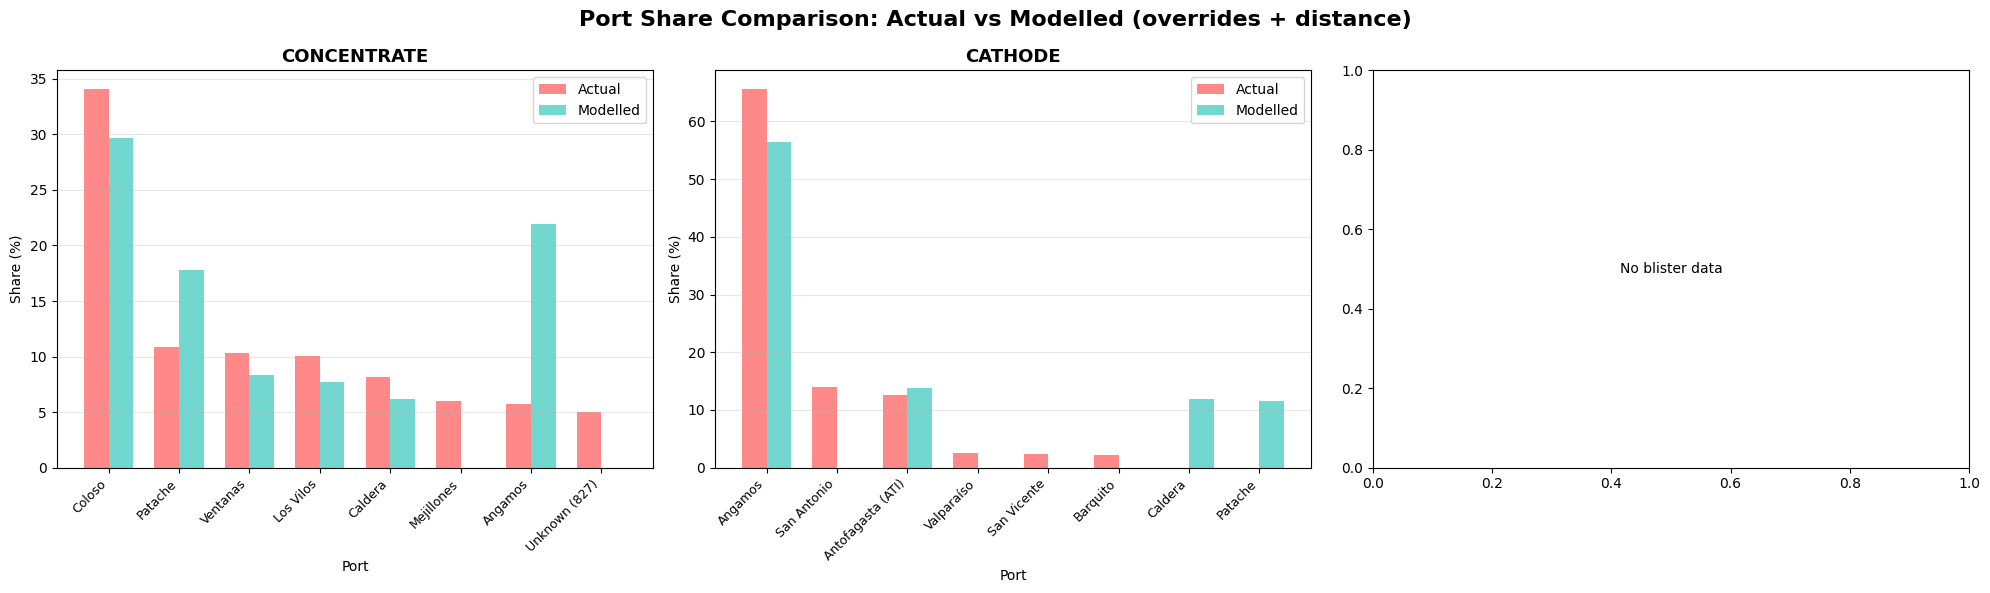

In [26]:

section_header("6. DISTANCE-BASED PORT ASSIGNMENT ANALYSIS")

mines = inv[
    (inv["CHAIN_STAGE"] == "extraction") & inv["LATITUD"].notna() &
    inv["LONGITUD"].notna() & (inv["COCHILCO_CU_2024_KMT"].notna()) &
    (inv["COCHILCO_CU_2024_KMT"] > 0)
].copy()

print(f"Mines with production data: {len(mines)}")
print(f"Ports: {len(ports_df)}")

# Product type classification
PRODUCT_TYPE_OVERRIDE = {
    "Spence": "concentrate", "Quebrada Blanca": "concentrate",
    "Centinela": "concentrate", "Sierra Gorda": "concentrate",
    "Caserones": "concentrate", "Andina": "concentrate",
    "Ministro Hales": "concentrate", "Las Luces": "cathode",
}

def classify_mine_product(mine_name):
    for key, ptype in PRODUCT_TYPE_OVERRIDE.items():
        if key.lower() in mine_name.lower():
            return ptype
    tokens = mine_name.split()
    search_terms = [" ".join(tokens[:2])] if len(tokens) >= 2 and tokens[0] in ("El", "Los", "Las", "La") else []
    search_terms.append(tokens[0] if len(tokens[0]) >= 5 else mine_name)
    for term in search_terms:
        candidates = inv[
            inv["FACILITY_NAME"].str.contains(term, case=False, na=False, regex=False) &
            ~inv["FACILITY_TYPE"].str.contains("Mine|Prospect", case=False, na=False)
        ]
        if len(candidates) > 0:
            stages = set(candidates["CHAIN_STAGE"].dropna())
            if stages & {"concentration", "smelting", "processing"}: return "concentrate"
            if "sx_ew" in stages: return "cathode"
    # Fallback: links mode
    mine_links = links[links["MINE_NAME"] == mine_name]
    if len(mine_links) > 0:
        mode = mine_links["PRODUCT_FORM"].value_counts().index[0]
        return {"concentrate": "concentrate", "cathode_sxew": "cathode", "cathode_er": "cathode", "blister": "blister"}.get(mode, "unknown")
    return "unknown"

mines["product_type"] = mines["FACILITY_NAME"].apply(classify_mine_product)
print(f"\nMines by product type:\n{mines['product_type'].value_counts().to_string()}")

# Distance matrix (vectorized)
mine_coords = mines[["LATITUD", "LONGITUD"]].values
port_coords = ports_df[["lat", "lon"]].values
distances = np.zeros((len(mines), len(ports_df)))
for i in range(len(mines)):
    for j in range(len(ports_df)):
        distances[i, j] = haversine_km(mine_coords[i, 0], mine_coords[i, 1], port_coords[j, 0], port_coords[j, 1])

distance_df = pd.DataFrame(distances, index=mines["FACILITY_NAME"].values, columns=ports_df["name"].values)

# Apply overrides: dedicated ports and Codelco cathode consolidation
def assign_port(mine_row, dist_row):
    """Assign port using: dedicated override > Codelco routing > nearest distance."""
    mine_name = mine_row["FACILITY_NAME"].lower()
    product = mine_row["product_type"]

    # 1. Dedicated port override (contractual)
    for key, port_name in DEDICATED_PORT.items():
        if key.lower() in mine_name and port_name in dist_row.index:
            return port_name, dist_row[port_name]

    # 2. Codelco cathode consolidation (for cathode-producing mines)
    if product == "cathode":
        for key, port_name in CODELCO_CATHODE_ROUTING.items():
            if key.lower() in mine_name and port_name in dist_row.index:
                return port_name, dist_row[port_name]

    # 3. Nearest port by distance (default)
    return dist_row.idxmin(), dist_row.min()

assigned_ports = []
assigned_dists = []
for i, (_, mine_row) in enumerate(mines.iterrows()):
    port_name, port_dist = assign_port(mine_row, distance_df.iloc[i])
    assigned_ports.append(port_name)
    assigned_dists.append(port_dist)

mines["nearest_port"] = assigned_ports
mines["distance_km"] = assigned_dists

print(f"\nTop 10 mines with assigned port (overrides + distance):")
for _, mine in mines.nlargest(10, "COCHILCO_CU_2024_KMT").iterrows():
    # Mark if override was used
    mine_lower = mine['FACILITY_NAME'].lower()
    is_override = any(k.lower() in mine_lower for k in DEDICATED_PORT) or \
                  (mine['product_type'] == 'cathode' and any(k.lower() in mine_lower for k in CODELCO_CATHODE_ROUTING))
    marker = " [override]" if is_override else ""
    print(f"  {mine['FACILITY_NAME']:<40} -> {mine['nearest_port']:<25} "
          f"({mine['distance_km']:.0f} km, {mine['COCHILCO_CU_2024_KMT']:.1f} kMT){marker}")

# Simulated shares
simulated_shares = {}
for product_type in ["concentrate", "cathode", "blister"]:
    product_mines = mines[mines["product_type"] == product_type]
    if len(product_mines) == 0: continue
    total_production = product_mines["COCHILCO_CU_2024_KMT"].sum()
    port_production = product_mines.groupby("nearest_port")["COCHILCO_CU_2024_KMT"].sum()
    port_shares = (port_production / total_production).to_dict()
    simulated_shares[product_type] = {k: v for k, v in port_shares.items() if v >= 0.01}
    print(f"\n{product_type.upper()} (modelled):")
    for port, share in sorted(simulated_shares[product_type].items(), key=lambda x: -x[1]):
        print(f"  {port:<30} {share*100:>6.1f}%")

# Compare to actual port shares
port_shares_path = os.path.join(DIR_PRELIM, "Chile_Port_Shares_Aduanas.csv")
if os.path.exists(port_shares_path):
    actual_shares_df = pd.read_csv(port_shares_path)
    ADUANAS_PORT_MAP = {"Caleta Coloso": "Coloso", "Puerto Angamos": "Angamos",
                        "Antofagasta": "Antofagasta (ATI)", "Chañaral/Barquito": "Barquito"}
    actual_shares_df["PORT"] = actual_shares_df["PORT"].replace(ADUANAS_PORT_MAP)

    actual_shares = {}
    for product in ["concentrate", "cathode", "blister"]:
        product_data = actual_shares_df[actual_shares_df["PRODUCT"] == product]
        if len(product_data) == 0: continue
        port_share_dict = product_data.groupby("PORT")["FOB_SHARE"].sum().to_dict()
        actual_shares[product] = {k: v for k, v in port_share_dict.items() if v >= 0.01}
        print(f"\n{product.upper()} (actual, Aduanas):")
        for port, share in sorted(actual_shares[product].items(), key=lambda x: -x[1]):
            print(f"  {port:<30} {share*100:>6.1f}%")

    # Comparison
    section_header("COMPARISON: ACTUAL vs MODELLED")
    comparison_results = []
    for product_type in ["concentrate", "cathode", "blister"]:
        if product_type not in simulated_shares: continue
        actual = actual_shares.get(product_type, {})
        simulated = simulated_shares[product_type]
        all_ports = set(actual.keys()) | set(simulated.keys())
        print(f"\n{product_type.upper()}\n" + "-" * 75)
        for port in sorted(all_ports):
            a, s = actual.get(port, 0), simulated.get(port, 0)
            diff = s - a
            indicator = "=" if abs(diff) < 0.02 else ("^ (would gain)" if diff > 0 else "v (would lose)")
            comparison_results.append({"product": product_type, "port": port,
                                       "actual_share": a, "simulated_share": s, "difference": diff})
            print(f"  {port:<30} Actual: {a*100:5.1f}%  |  Modelled: {s*100:5.1f}%  |  D {diff*100:+6.1f}% {indicator}")

    comparison_df = pd.DataFrame(comparison_results)

    section_header("SUMMARY STATISTICS")
    for product_type in ["concentrate", "cathode", "blister"]:
        pc = comparison_df[comparison_df["product"] == product_type]
        if len(pc) == 0: continue
        print(f"\n{product_type.upper()}:")
        print(f"  Mean Absolute Difference: {pc['difference'].abs().mean()*100:.1f}%")
        print(f"  Total Volume Mismatch: {pc['difference'].abs().sum()/2*100:.1f}%")

    # Save comparison outputs
    comparison_df.to_csv(os.path.join(DIR_PRELIM, "Port_Distance_Comparison.csv"), index=False)
    mines[["FACILITY_NAME", "COCHILCO_CU_2024_KMT", "product_type", "nearest_port", "distance_km"]].to_csv(
        os.path.join(DIR_PRELIM, "Mine_Optimal_Port_Assignments.csv"), index=False)
    distance_df.to_csv(os.path.join(DIR_PRELIM, "Mine_Port_Distance_Matrix.csv"))

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle("Port Share Comparison: Actual vs Modelled (overrides + distance)", fontsize=16, fontweight="bold")
    colors = {"actual": "#FF6B6B", "simulated": "#4ECDC4"}

    for idx, product in enumerate(["concentrate", "cathode", "blister"]):
        ax = axes[idx]
        if product not in simulated_shares:
            ax.text(0.5, 0.5, f"No {product} data", ha="center", va="center", transform=ax.transAxes)
            continue
        pd_data = comparison_df[comparison_df["product"] == product].copy()
        pd_data = pd_data.sort_values("actual_share", ascending=False)
        pd_data = pd_data[(pd_data["actual_share"] >= 0.01) | (pd_data["simulated_share"] >= 0.01)].head(8)
        if len(pd_data) == 0: continue
        x = np.arange(len(pd_data))
        width = 0.35
        ax.bar(x - width/2, pd_data["actual_share"] * 100, width, label="Actual", color=colors["actual"], alpha=0.8)
        ax.bar(x + width/2, pd_data["simulated_share"] * 100, width, label="Modelled", color=colors["simulated"], alpha=0.8)
        ax.set_xlabel("Port"); ax.set_ylabel("Share (%)")
        ax.set_title(f"{product.upper()}", fontsize=13, fontweight="bold")
        ax.set_xticks(x); ax.set_xticklabels(pd_data["port"], rotation=45, ha="right", fontsize=9)
        ax.legend(); ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(DIR_PRELIM, "Port_Comparison_Chart.png"), dpi=300, bbox_inches="tight")
    print(f"\nChart saved: Port_Comparison_Chart.png")
    plt.show()
else:
    print("\nWarning: Chile_Port_Shares_Aduanas.csv not found, only simulated shares shown")
